In [12]:
import os, gc, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_properties(0).name}")

Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [13]:
SEED       = 42
EMBED_DIM  = 512
NUM_PROT   = 4
LSIG_LEN   = 24
HTSIG_LEN  = 48
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True

In [14]:
import os
os.makedirs('/workspace/data', exist_ok=True)

print("Loading data...")
train_data = torch.load('/workspace/data/train.pt')
test_data  = torch.load('/workspace/data/test.pt')

high_train, low_train, prot_train, lsig_train, htsig_train, has_htsig_train = train_data
high_test,  low_test,  prot_test,  lsig_test,  htsig_test,  has_htsig_test  = test_data

print(f"Train: {len(prot_train):,} samples")
print(f"Test:  {len(prot_test):,} samples")

Loading data...
Train: 86,437 samples
Test:  9,725 samples


In [16]:
class AugmentedDataset(Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()
        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t
        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

def task_loss_balanced(prot_l, lsig_l, htsig_l,
                       prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0]).to(prot_l.device).to(prot_l.dtype)
    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss = loss + F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets).float().mean().item()

def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159265)).item())
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

@torch.no_grad()
def evaluate(model, loader, use_high=False):
    model.eval()
    tot_loss = tot_prot = tot_lsig = 0
    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        iq        = (high_iq if use_high else low_iq).to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = model(iq)
        loss = task_loss_balanced(
            prot_l.float(), lsig_l.float(), htsig_l.float(),
            prot, lsig.float(), htsig.float(), has_htsig)
        tot_loss += loss.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)
    n = len(loader)
    return tot_loss/n, tot_prot/n, tot_lsig/n

train_ds = AugmentedDataset(train_data, augment=True)
test_ds  = AugmentedDataset(test_data,  augment=False)
print("Setup complete")

Setup complete


In [17]:
import time, gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

gc.collect()
torch.cuda.empty_cache()

In [20]:
# ── STFT + 2D CNN Model ───────────────────────────────────────────────────
class STFTModel(nn.Module):
    """
    Converts IQ signal to spectrogram via STFT then classifies with 2D CNN.
    This is how most modern RF papers work — treat it like image classification.
    
    STFT converts: (2, 2000) → (2, freq_bins, time_steps) spectrogram
    Then 2D CNN processes it like an image.
    """
    def __init__(self, n_fft=128, hop_length=32, embed_dim=512):
        super().__init__()
        self.n_fft      = n_fft
        self.hop_length = hop_length
        freq_bins       = n_fft // 2 + 1  # 65 frequency bins

        # 2D CNN — treats spectrogram like an image
        self.cnn = nn.Sequential(
            # Input: (B, 2, 65, ~63) — 2 channels (I and Q spectrograms)
            nn.Conv2d(2, 32,  kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.GELU(),
            nn.MaxPool2d(2),  # → (B, 64, 32, ~31)

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.MaxPool2d(2),  # → (B, 256, 16, ~15)

            nn.Conv2d(256, embed_dim, kernel_size=3, padding=1), nn.BatchNorm2d(embed_dim), nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1))  # → (B, embed_dim, 1, 1)
        )

        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def compute_stft(self, x):
        """Convert IQ signal to magnitude spectrogram."""
        B = x.shape[0]
        window = torch.hann_window(self.n_fft).to(x.device)

        specs = []
        for ch in range(2):  # I and Q channels separately
            signal = x[:, ch, :]  # (B, 2000)
            # Compute STFT for each sample in batch
            spec_batch = []
            for b in range(B):
                stft = torch.stft(signal[b], n_fft=self.n_fft,
                                  hop_length=self.hop_length,
                                  window=window, return_complex=True)
                mag = torch.abs(stft)  # (freq_bins, time_steps)
                spec_batch.append(mag)
            specs.append(torch.stack(spec_batch))  # (B, freq_bins, time_steps)

        return torch.stack(specs, dim=1)  # (B, 2, freq_bins, time_steps)

    def forward(self, x):
        spec = self.compute_stft(x)           # (B, 2, 65, ~63)
        emb  = self.cnn(spec).squeeze(-1).squeeze(-1)  # (B, embed_dim)
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb

In [19]:
# ── Sanity check ──────────────────────────────────────────────────────────
test_stft = STFTModel().to(DEVICE)
dummy = torch.randn(4, 2, 2000).to(DEVICE)
with torch.no_grad():
    out = test_stft(dummy)
total_params = sum(p.numel() for p in test_stft.parameters())
print(f"STFT+CNN output: prot={out[0].shape} emb={out[3].shape}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_stft
gc.collect()
torch.cuda.empty_cache()


STFT+CNN output: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Parameters: 1,777,068 (7.1 MB)


In [20]:
# ── Training ──────────────────────────────────────────────────────────────
STFT_EPOCHS   = 40
STFT_LR       = 1e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 1

train_loader = DataLoader(train_ds, batch_size=128,  # smaller batch — STFT is memory heavy
                          shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128,
                          shuffle=False, num_workers=0, pin_memory=True)

stft_model  = STFTModel().to(DEVICE)
s_opt       = torch.optim.AdamW(stft_model.parameters(), lr=STFT_LR, weight_decay=1e-4)
s_sched     = get_scheduler_with_warmup(s_opt, WARMUP_EPOCHS, STFT_EPOCHS)
s_scaler    = torch.amp.GradScaler('cuda')
best_s_prot = 0.0

print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'lr':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, STFT_EPOCHS + 1):
    stft_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    s_opt.zero_grad()

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = stft_model(low_iq)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        s_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
            s_scaler.unscale_(s_opt)
            torch.nn.utils.clip_grad_norm_(stft_model.parameters(), 1.0)
            s_scaler.step(s_opt)
            s_scaler.update()
            s_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    s_sched.step()
    n  = len(train_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(stft_model, test_loader, use_high=False)
    lr = s_opt.param_groups[0]['lr']

    if va[1] > best_s_prot:
        best_s_prot = va[1]
        torch.save(stft_model.state_dict(), '/workspace/stft_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {lr:8.2e} {time.time()-t0:5.0f}s{marker}")

print(f"\nBest STFT+CNN va_prot: {best_s_prot:.4f}")


 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.5591    0.818    0.859    0.829    0.882 6.67e-05    19s <- best
  2   0.9324    0.938    0.889    0.919    0.903 1.00e-04    15s <- best
  3   0.7702    0.962    0.916    0.948    0.920 1.00e-04    15s <- best
  4   0.6736    0.975    0.929    0.939    0.927 9.98e-05    15s
  5   0.5948    0.980    0.941    0.940    0.925 9.93e-05    14s
  6   0.5243    0.981    0.949    0.948    0.941 9.84e-05    15s <- best
  7   0.4787    0.983    0.955    0.950    0.939 9.71e-05    15s <- best
  8   0.4488    0.984    0.959    0.936    0.950 9.56e-05    15s
  9   0.4269    0.985    0.962    0.949    0.949 9.37e-05    15s
 10   0.4053    0.985    0.965    0.948    0.953 9.14e-05    14s
 11   0.3906    0.986    0.968    0.940    0.952 8.89e-05    15s
 12   0.3780    0.986    0.969    0.930    0.947 8.61e-05    15s
 13   0.3619    0.986    0.971    0.941    

In [21]:
# ── Per-class accuracy ────────────────────────────────────────────────────
stft_model.load_state_dict(torch.load('/workspace/stft_best.pt'))
stft_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = stft_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (STFT+2D CNN):")
print(f"{'Class':>8} {'STFT':>8} {'TCN':>8} {'CNN+Trans':>12}")
print("-" * 40)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc = correct[c]/(total[c]+1e-8) * 100
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>7.1f}%  {'?':>6}  {cnn_trans[c]:>10.1f}%")



Per-class accuracy (STFT+2D CNN):
   Class     STFT      TCN    CNN+Trans
----------------------------------------
  Non-HT:    97.9%       ?        97.0%
      HT:    92.2%       ?        91.9%
     VHT:    52.8%       ?        58.0%
    HTGF:    50.0%       ?        50.0%


STFT 2D CNN

```
 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig       lr   time
----------------------------------------------------------------------
  1   1.5591    0.818    0.859    0.829    0.882 6.67e-05    19s <- best
  2   0.9324    0.938    0.889    0.919    0.903 1.00e-04    15s <- best
  3   0.7702    0.962    0.916    0.948    0.920 1.00e-04    15s <- best
  4   0.6736    0.975    0.929    0.939    0.927 9.98e-05    15s
  5   0.5948    0.980    0.941    0.940    0.925 9.93e-05    14s
  6   0.5243    0.981    0.949    0.948    0.941 9.84e-05    15s <- best
  7   0.4787    0.983    0.955    0.950    0.939 9.71e-05    15s <- best
  8   0.4488    0.984    0.959    0.936    0.950 9.56e-05    15s
  9   0.4269    0.985    0.962    0.949    0.949 9.37e-05    15s
 10   0.4053    0.985    0.965    0.948    0.953 9.14e-05    14s
 11   0.3906    0.986    0.968    0.940    0.952 8.89e-05    15s
 12   0.3780    0.986    0.969    0.930    0.947 8.61e-05    15s
 13   0.3619    0.986    0.971    0.941    0.956 8.30e-05    15s
 14   0.3467    0.987    0.972    0.933    0.956 7.97e-05    15s
 15   0.3323    0.987    0.973    0.914    0.953 7.62e-05    15s
 16   0.3205    0.987    0.973    0.922    0.949 7.25e-05    15s
 17   0.3063    0.988    0.974    0.939    0.959 6.86e-05    15s
 18   0.2928    0.989    0.975    0.938    0.960 6.46e-05    15s
 19   0.2779    0.990    0.975    0.947    0.957 6.05e-05    15s
 20   0.2626    0.990    0.976    0.913    0.961 5.64e-05    15s
 21   0.2504    0.991    0.976    0.953    0.961 5.21e-05    15s <- best
 22   0.2449    0.992    0.977    0.945    0.961 4.79e-05    15s
 23   0.2324    0.992    0.977    0.936    0.960 4.36e-05    15s
 24   0.2229    0.993    0.978    0.928    0.964 3.95e-05    15s
 25   0.2151    0.993    0.978    0.946    0.962 3.54e-05    15s
 26   0.2099    0.995    0.978    0.955    0.963 3.14e-05    15s <- best
 27   0.2019    0.995    0.979    0.944    0.964 2.75e-05    15s
 28   0.1935    0.996    0.979    0.945    0.963 2.38e-05    15s
 29   0.1918    0.996    0.979    0.950    0.963 2.03e-05    15s
 30   0.1838    0.997    0.979    0.947    0.964 1.70e-05    15s
 31   0.1809    0.997    0.980    0.949    0.965 1.39e-05    15s
 32   0.1790    0.997    0.980    0.947    0.965 1.11e-05    15s
 33   0.1753    0.997    0.980    0.951    0.965 8.57e-06    15s
 34   0.1718    0.998    0.980    0.950    0.965 6.35e-06    15s
 35   0.1725    0.998    0.980    0.951    0.965 4.44e-06    15s
 36   0.1699    0.998    0.980    0.951    0.965 2.86e-06    14s
 37   0.1696    0.998    0.980    0.952    0.965 1.61e-06    15s
 38   0.1683    0.998    0.980    0.950    0.965 7.19e-07    15s
 39   0.1664    0.998    0.980    0.951    0.965 1.80e-07    15s
 40   0.1674    0.998    0.980    0.950    0.965 0.00e+00    15s

Best STFT+CNN va_prot: 0.9551


Per-class accuracy (STFT+2D CNN):
   Class     STFT      TCN    CNN+Trans
----------------------------------------
  Non-HT:    97.9%       ?        97.0%
      HT:    92.2%       ?        91.9%
     VHT:    52.8%       ?        58.0%
    HTGF:    50.0%       ?        50.0%
```

In [24]:
class AntiCurriculumDataset(torch.utils.data.Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment   = augment
        self.low_ratio = 1.0

    def set_low_ratio(self, ratio):
        self.low_ratio = ratio

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t

        use_low = torch.rand(1).item() < self.low_ratio
        signal  = low if use_low else high

        # Normalize to same length — upsample low-res to 8000
        if signal.shape[-1] != 8000:
            signal = F.interpolate(signal.unsqueeze(0), size=8000,
                                   mode='linear', align_corners=False).squeeze(0)
        return signal, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

# Recreate dataset and loader
ac_ds     = AntiCurriculumDataset(train_data, augment=True)
ac_loader = DataLoader(ac_ds, batch_size=256, shuffle=True,
                       num_workers=0, pin_memory=True)

In [25]:
# Clear old model and restart completely
import gc
try:
    del ac_model
except: pass
gc.collect()
torch.cuda.empty_cache()

# Reinit everything fresh
ac_model    = ACModel().to(DEVICE)
a_opt       = torch.optim.AdamW(ac_model.parameters(), lr=AC_LR, weight_decay=1e-4)
a_sched     = get_scheduler_with_warmup(a_opt, WARMUP_EPOCHS, AC_EPOCHS)
a_scaler    = torch.amp.GradScaler('cuda')
best_a_prot = 0.0

print("Ready — rerun training loop now ✅")

# ── Anti-Curriculum Dataset ───────────────────────────────────────────────
class AntiCurriculumDataset(torch.utils.data.Dataset):
    """
    NOVEL: Hard -> Easy -> Hard training schedule.
    
    Theory: Struggling on hard examples early forces the model to learn
    more robust features. Then easy examples consolidate knowledge.
    Then hard again for final fine-tuning.
    
    Schedule:
    Epochs 1-10:  100% low-res  (hardest — struggle early)
    Epochs 11-20: 50% low-res, 50% high-res (mixed — consolidate)
    Epochs 21-30: 100% high-res (easiest — solidify representations)
    Epochs 31-40: 100% low-res  (hard again — final fine-tune)
    """
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment   = augment
        self.low_ratio = 1.0  # start with 100% low-res (hardest)

    def set_low_ratio(self, ratio):
        self.low_ratio = ratio

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t

        use_low = torch.rand(1).item() < self.low_ratio
        signal  = low if use_low else high
        return signal, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]


def get_anti_curriculum_ratio(epoch, total_epochs=40):
    """Anti-curriculum: hard -> easy -> hard"""
    if epoch <= 10:   return 1.0   # 100% low-res (hard)
    elif epoch <= 20: return 0.5   # 50/50 (mixed)
    elif epoch <= 30: return 0.0   # 100% high-res (easy)
    else:             return 1.0   # 100% low-res again (hard fine-tune)


# ── Model ─────────────────────────────────────────────────────────────────
class IQEncoder_AC(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64,  kernel_size=7, stride=2, padding=3), nn.BatchNorm1d(64),  nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(256), nn.GELU(),
            nn.Conv1d(256, 384, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(embed_dim), nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8, dim_feedforward=1024,
            dropout=0.1, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4,
                                                  enable_nested_tensor=False)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat   = self.cnn(x)
        feat_t = self.transformer(feat.permute(0,2,1)).permute(0,2,1)
        return self.pool(feat_t).squeeze(-1), feat


class WiFiDecoder_AC(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, emb):
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb)


class ACModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = IQEncoder_AC()
        self.decoder = WiFiDecoder_AC()

    def forward(self, x):
        emb, feat = self.encoder(x)
        prot_l, lsig_l, htsig_l = self.decoder(emb)
        return prot_l, lsig_l, htsig_l, emb, emb, emb


# ── Sanity check ──────────────────────────────────────────────────────────
test_ac  = ACModel().to(DEVICE)
dummy_hi = torch.randn(4, 2, 8000).to(DEVICE)
dummy_lo = torch.randn(4, 2, 2000).to(DEVICE)
with torch.no_grad():
    out_hi = test_ac(dummy_hi)
    out_lo = test_ac(dummy_lo)
total_params = sum(p.numel() for p in test_ac.parameters())
print(f"ACModel high-res: prot={out_hi[0].shape} emb={out_hi[3].shape}")
print(f"ACModel low-res:  prot={out_lo[0].shape} emb={out_lo[3].shape}")
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
del test_ac
gc.collect()
torch.cuda.empty_cache()

# ── Training ──────────────────────────────────────────────────────────────
AC_EPOCHS     = 40
AC_LR         = 5e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 2

ac_ds       = AntiCurriculumDataset(train_data, augment=True)
ac_loader   = DataLoader(ac_ds, batch_size=256,
                         shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=256,
                         shuffle=False, num_workers=0, pin_memory=True)

ac_model    = ACModel().to(DEVICE)
a_opt       = torch.optim.AdamW(ac_model.parameters(), lr=AC_LR, weight_decay=1e-4)
a_sched     = get_scheduler_with_warmup(a_opt, WARMUP_EPOCHS, AC_EPOCHS)
a_scaler    = torch.amp.GradScaler('cuda')
best_a_prot = 0.0

print(f"\n{'Ep':>3} {'lo_ratio':>9} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'time':>6}")
print("-" * 75)

for epoch in range(1, AC_EPOCHS + 1):
    low_ratio = get_anti_curriculum_ratio(epoch, AC_EPOCHS)
    ac_ds.set_low_ratio(low_ratio)

    ac_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    a_opt.zero_grad()

    for i, (signal, prot, lsig, htsig, has_htsig) in enumerate(ac_loader):
        signal    = signal.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = ac_model(signal)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        a_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(ac_loader):
            a_scaler.unscale_(a_opt)
            torch.nn.utils.clip_grad_norm_(ac_model.parameters(), 1.0)
            a_scaler.step(a_opt)
            a_scaler.update()
            a_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    a_sched.step()
    n  = len(ac_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(ac_model, test_loader, use_high=False)
    elapsed = time.time() - t0

    if va[1] > best_a_prot:
        best_a_prot = va[1]
        torch.save(ac_model.state_dict(), '/workspace/anti_curriculum_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {low_ratio:9.2f} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {elapsed:5.0f}s{marker}")

print(f"\nBest Anti-Curriculum va_prot: {best_a_prot:.4f}")

# ── Per-class accuracy ────────────────────────────────────────────────────
ac_model.load_state_dict(torch.load('/workspace/anti_curriculum_best.pt'))
ac_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = ac_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (Anti-Curriculum):")
print(f"{'Class':>8} {'Anti-Curr':>10} {'CNN+Trans':>12} {'Diff':>8}")
print("-" * 44)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc  = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - cnn_trans[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>9.1f}%  {cnn_trans[c]:>10.1f}%  {diff:>+6.1f}%")

ACModel high-res: prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
ACModel low-res:  prot=torch.Size([4, 4]) emb=torch.Size([4, 512])
Parameters: 9,646,860 (38.6 MB)

 Ep  lo_ratio  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig   time
---------------------------------------------------------------------------
  1      1.00   1.1095    0.855    0.882    0.928    0.904     9s <- best
  2      1.00   0.7087    0.959    0.920    0.937    0.934     9s <- best
  3      1.00   0.5697    0.969    0.947    0.939    0.944     9s <- best
  4      1.00   0.4925    0.972    0.958    0.940    0.953     9s <- best
  5      1.00   0.4481    0.974    0.965    0.939    0.956     9s
  6      1.00   0.4168    0.976    0.969    0.925    0.957     9s
  7      1.00   0.3941    0.976    0.972    0.942    0.958     9s <- best
  8      1.00   0.3799    0.977    0.973    0.933    0.960     9s
  9      1.00   0.3658    0.976    0.974    0.930    0.961     9s
 10      1.00   0.3490    0.978    0.976    0.946    0.96

RuntimeError: stack expects each tensor to be equal size, but got [2, 2000] at entry 0 and [2, 8000] at entry 1

In [26]:
import time, gc, os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# ── Setup ──────────────────────────────────────────────────────────────────
SEED       = 42
EMBED_DIM  = 512
NUM_PROT   = 4
LSIG_LEN   = 24
HTSIG_LEN  = 48
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_properties(0).name}")

# ── Load Data ──────────────────────────────────────────────────────────────
print("Loading data...")
os.makedirs('/workspace/data', exist_ok=True)
train_data = torch.load('/workspace/data/train.pt')
test_data  = torch.load('/workspace/data/test.pt')
high_train, low_train, prot_train, lsig_train, htsig_train, has_htsig_train = train_data
print(f"Train: {len(prot_train):,} | Test: {len(test_data[2]):,}")

# ── Loss Functions ─────────────────────────────────────────────────────────
def task_loss_balanced(prot_l, lsig_l, htsig_l,
                       prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0]).to(prot_l.device).to(prot_l.dtype)
    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss = loss + F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets).float().mean().item()

def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159265)).item())
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Evaluate ───────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot_loss = tot_prot = tot_lsig = 0
    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        iq        = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = model(iq)
        loss = task_loss_balanced(
            prot_l.float(), lsig_l.float(), htsig_l.float(),
            prot, lsig.float(), htsig.float(), has_htsig)
        tot_loss += loss.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)
    n = len(loader)
    return tot_loss/n, tot_prot/n, tot_lsig/n

# ── Standard Dataset for eval ──────────────────────────────────────────────
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()
        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t
        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

# ── Anti-Curriculum Dataset ────────────────────────────────────────────────
class AntiCurriculumDataset(torch.utils.data.Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment   = augment
        self.low_ratio = 1.0

    def set_low_ratio(self, ratio):
        self.low_ratio = ratio

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t

        use_low = torch.rand(1).item() < self.low_ratio
        signal  = low if use_low else high

        # Always normalize to 8000 samples so batches can stack
        if signal.shape[-1] != 8000:
            signal = F.interpolate(signal.unsqueeze(0), size=8000,
                                   mode='linear', align_corners=False).squeeze(0)
        return signal, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]


def get_anti_curriculum_ratio(epoch, total_epochs=40):
    if epoch <= 10:   return 1.0
    elif epoch <= 20: return 0.5
    elif epoch <= 30: return 0.0
    else:             return 1.0

# ── Model ──────────────────────────────────────────────────────────────────
class IQEncoder_AC(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64,  kernel_size=7, stride=2, padding=3), nn.BatchNorm1d(64),  nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(256), nn.GELU(),
            nn.Conv1d(256, 384, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(embed_dim), nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8, dim_feedforward=1024,
            dropout=0.1, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4,
                                                  enable_nested_tensor=False)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat   = self.cnn(x)
        feat_t = self.transformer(feat.permute(0,2,1)).permute(0,2,1)
        return self.pool(feat_t).squeeze(-1), feat


class WiFiDecoder_AC(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def forward(self, emb):
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb)


class ACModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = IQEncoder_AC()
        self.decoder = WiFiDecoder_AC()

    def forward(self, x):
        emb, feat = self.encoder(x)
        prot_l, lsig_l, htsig_l = self.decoder(emb)
        return prot_l, lsig_l, htsig_l, emb, emb, emb

# ── Training ───────────────────────────────────────────────────────────────
AC_EPOCHS     = 40
AC_LR         = 5e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 2

test_ds     = AugmentedDataset(test_data, augment=False)
ac_ds       = AntiCurriculumDataset(train_data, augment=True)
ac_loader   = DataLoader(ac_ds, batch_size=256, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

ac_model    = ACModel().to(DEVICE)
a_opt       = torch.optim.AdamW(ac_model.parameters(), lr=AC_LR, weight_decay=1e-4)
a_sched     = get_scheduler_with_warmup(a_opt, WARMUP_EPOCHS, AC_EPOCHS)
a_scaler    = torch.amp.GradScaler('cuda')
best_a_prot = 0.0

total_params = sum(p.numel() for p in ac_model.parameters())
print(f"Parameters: {total_params:,} ({total_params*4/1e6:.1f} MB)")
print(f"\n{'Ep':>3} {'lo_ratio':>9} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'time':>6}")
print("-" * 75)

for epoch in range(1, AC_EPOCHS + 1):
    low_ratio = get_anti_curriculum_ratio(epoch, AC_EPOCHS)
    ac_ds.set_low_ratio(low_ratio)

    ac_model.train()
    t0 = time.time()
    tot_loss = tot_prot = tot_lsig = 0
    a_opt.zero_grad()

    for i, (signal, prot, lsig, htsig, has_htsig) in enumerate(ac_loader):
        signal    = signal.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, htsig_l, _, _, _ = ac_model(signal)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                      prot, lsig, htsig, has_htsig) / ACCUM_STEPS

        a_scaler.scale(loss).backward()
        if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(ac_loader):
            a_scaler.unscale_(a_opt)
            torch.nn.utils.clip_grad_norm_(ac_model.parameters(), 1.0)
            a_scaler.step(a_opt)
            a_scaler.update()
            a_opt.zero_grad()

        tot_loss += loss.item() * ACCUM_STEPS
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)

    a_sched.step()
    n  = len(ac_loader)
    tr = (tot_loss/n, tot_prot/n, tot_lsig/n)
    va = evaluate(ac_model, test_loader)
    lr = a_opt.param_groups[0]['lr']
    elapsed = time.time() - t0

    if va[1] > best_a_prot:
        best_a_prot = va[1]
        torch.save(ac_model.state_dict(), '/workspace/anti_curriculum_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {low_ratio:9.2f} {tr[0]:8.4f} {tr[1]:8.3f} {tr[2]:8.3f} "
          f"{va[1]:8.3f} {va[2]:8.3f} {elapsed:5.0f}s{marker}", flush=True)

print(f"\nBest Anti-Curriculum va_prot: {best_a_prot:.4f}")

# ── Per-class accuracy ─────────────────────────────────────────────────────
ac_model.load_state_dict(torch.load('/workspace/anti_curriculum_best.pt'))
ac_model.eval()
correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            prot_l, _, _, _, _, _ = ac_model(iq)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (Anti-Curriculum):")
print(f"{'Class':>8} {'Anti-Curr':>10} {'CNN+Trans':>12} {'Diff':>8}")
print("-" * 44)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc  = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - cnn_trans[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>9.1f}%  {cnn_trans[c]:>10.1f}%  {diff:>+6.1f}%")

Device: cuda
GPU: NVIDIA GeForce RTX 5090
Loading data...
Train: 86,437 | Test: 9,725
Parameters: 9,646,860 (38.6 MB)

 Ep  lo_ratio  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig   time
---------------------------------------------------------------------------
  1      1.00   1.2602    0.760    0.882    0.242    0.856    33s <- best
  2      1.00   0.8770    0.899    0.902    0.118    0.853    32s
  3      1.00   0.7163    0.937    0.919    0.206    0.847    32s
  4      1.00   0.6105    0.955    0.933    0.111    0.838    32s
  5      1.00   0.5353    0.963    0.941    0.111    0.825    32s
  6      1.00   0.4895    0.966    0.948    0.122    0.842    32s
  7      1.00   0.4564    0.971    0.955    0.113    0.831    32s
  8      1.00   0.4295    0.971    0.960    0.270    0.830    32s <- best
  9      1.00   0.4087    0.973    0.965    0.181    0.818    32s
 10      1.00   0.3888    0.976    0.968    0.224    0.833    32s
 11      0.50   0.7214    0.915    0.935    0.849    0.878    3

```
Device: cuda
GPU: NVIDIA GeForce RTX 5090
Loading data...
Train: 86,437 | Test: 9,725
Parameters: 9,646,860 (38.6 MB)

 Ep  lo_ratio  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig   time
---------------------------------------------------------------------------
  1      1.00   1.2602    0.760    0.882    0.242    0.856    33s <- best
  2      1.00   0.8770    0.899    0.902    0.118    0.853    32s
  3      1.00   0.7163    0.937    0.919    0.206    0.847    32s
  4      1.00   0.6105    0.955    0.933    0.111    0.838    32s
  5      1.00   0.5353    0.963    0.941    0.111    0.825    32s
  6      1.00   0.4895    0.966    0.948    0.122    0.842    32s
  7      1.00   0.4564    0.971    0.955    0.113    0.831    32s
  8      1.00   0.4295    0.971    0.960    0.270    0.830    32s <- best
  9      1.00   0.4087    0.973    0.965    0.181    0.818    32s
 10      1.00   0.3888    0.976    0.968    0.224    0.833    32s
 11      0.50   0.7214    0.915    0.935    0.849    0.878    31s <- best
 12      0.50   0.4918    0.966    0.949    0.844    0.874    31s
 13      0.50   0.4218    0.975    0.955    0.858    0.868    31s <- best
 14      0.50   0.3950    0.977    0.959    0.859    0.866    31s <- best
 15      0.50   0.3629    0.979    0.962    0.847    0.867    31s
 16      0.50   0.3479    0.980    0.964    0.838    0.867    31s
 17      0.50   0.3349    0.980    0.966    0.834    0.857    31s
 18      0.50   0.3139    0.982    0.970    0.847    0.863    31s
 19      0.50   0.2934    0.984    0.973    0.785    0.858    31s
 20      0.50   0.2864    0.984    0.974    0.758    0.860    31s
 21      0.00   0.2116    0.992    0.978    0.714    0.864    29s
 22      0.00   0.1834    0.994    0.982    0.713    0.864    29s
 23      0.00   0.1632    0.995    0.984    0.497    0.845    29s
 24      0.00   0.1513    0.996    0.985    0.402    0.844    29s
 25      0.00   0.1392    0.997    0.987    0.560    0.853    29s
 26      0.00   0.1320    0.997    0.987    0.318    0.838    29s
 27      0.00   0.1238    0.998    0.988    0.462    0.847    29s
 28      0.00   0.1175    0.998    0.989    0.467    0.841    29s
 29      0.00   0.1135    0.998    0.989    0.547    0.835    29s
 30      0.00   0.1081    0.999    0.990    0.583    0.835    29s
 31      1.00   0.3848    0.972    0.969    0.748    0.835    32s
 32      1.00   0.2979    0.980    0.976    0.756    0.834    32s
 33      1.00   0.2758    0.981    0.977    0.708    0.833    32s
 34      1.00   0.2571    0.983    0.978    0.704    0.834    32s
 35      1.00   0.2467    0.983    0.978    0.674    0.829    32s
 36      1.00   0.2373    0.985    0.979    0.672    0.829    33s
 37      1.00   0.2319    0.985    0.979    0.660    0.826    32s
 38      1.00   0.2273    0.985    0.979    0.671    0.826    32s
 39      1.00   0.2239    0.986    0.979    0.675    0.826    32s
 40      1.00   0.2226    0.986    0.979    0.674    0.826    32s

Best Anti-Curriculum va_prot: 0.8591

Per-class accuracy (Anti-Curriculum):
   Class  Anti-Curr    CNN+Trans     Diff
--------------------------------------------
  Non-HT:      99.0%        97.0%    +2.0%
      HT:      15.2%        91.9%   -76.7%
     VHT:       0.0%        58.0%   -58.0%
    HTGF:       0.0%        50.0%   -50.0%
    ```

In [27]:
import time, gc, os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# ── Setup ──────────────────────────────────────────────────────────────────
SEED       = 42
EMBED_DIM  = 512
NUM_PROT   = 4
LSIG_LEN   = 24
HTSIG_LEN  = 48
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_properties(0).name}")

# ── Load Data ──────────────────────────────────────────────────────────────
print("Loading data...")
train_data = torch.load('/workspace/data/train.pt')
test_data  = torch.load('/workspace/data/test.pt')
high_train, low_train, prot_train, lsig_train, htsig_train, has_htsig_train = train_data
print(f"Train: {len(prot_train):,} | Test: {len(test_data[2]):,}")

# ── Helpers ────────────────────────────────────────────────────────────────
def task_loss_balanced(prot_l, lsig_l, htsig_l, prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0]).to(prot_l.device).to(prot_l.dtype)
    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss = loss + F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss = loss + F.binary_cross_entropy_with_logits(
                        htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets).float().mean().item()

def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159265)).item())
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()
        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * 3.14159265).item()
            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))
            for iq in (high, low):
                real  = iq[0].clone()
                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t
        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

# ── Generator (low-res → fake high-res) ───────────────────────────────────
class Generator(nn.Module):
    """
    NOVEL: Signal Hallucination GAN.
    Generates plausible high-res signals from low-res inputs.
    The classifier then operates on the hallucinated high-res signal.
    """
    def __init__(self):
        super().__init__()
        # Upsample 2000 → 8000
        self.net = nn.Sequential(
            # Initial feature extraction
            nn.Conv1d(2, 64, kernel_size=7, padding=3), nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.GELU(),

            # Upsample 2000 → 4000
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64), nn.GELU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1), nn.GELU(),

            # Upsample 4000 → 8000
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32), nn.GELU(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1), nn.GELU(),

            # Output projection
            nn.Conv1d(32, 2, kernel_size=7, padding=3),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)  # (B, 2, 8000)


# ── Discriminator (real vs fake high-res) ─────────────────────────────────
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=7, stride=2, padding=3), nn.LeakyReLU(0.2),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2), nn.LeakyReLU(0.2),
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1), nn.LeakyReLU(0.2),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(256, 1)

    def forward(self, x):
        feat = self.net(x).squeeze(-1)
        return self.head(feat)


# ── Classifier (operates on hallucinated high-res) ────────────────────────
class IQEncoder_GAN(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(2, 64,  kernel_size=7, stride=2, padding=3), nn.BatchNorm1d(64),  nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), nn.BatchNorm1d(128), nn.GELU(),
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(256), nn.GELU(),
            nn.Conv1d(256, 384, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(384), nn.GELU(),
            nn.Conv1d(384, embed_dim, kernel_size=3, stride=2, padding=1), nn.BatchNorm1d(embed_dim), nn.GELU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=8, dim_feedforward=2048,
            dropout=0.1, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6,
                                                  enable_nested_tensor=False)
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        feat   = self.cnn(x)
        feat_t = self.transformer(feat.permute(0,2,1)).permute(0,2,1)
        return self.pool(feat_t).squeeze(-1), feat


class GANClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder    = IQEncoder_GAN()
        self.prot_head  = nn.Sequential(nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.1), nn.Linear(256, HTSIG_LEN))

    def forward(self, x):
        emb, feat = self.encoder(x)
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb


# ── Evaluate ───────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(generator, classifier, loader):
    generator.eval()
    classifier.eval()
    tot_loss = tot_prot = tot_lsig = 0
    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        low_iq    = low_iq.to(DEVICE)
        prot      = prot.to(DEVICE)
        lsig      = lsig.to(DEVICE)
        htsig     = htsig.to(DEVICE)
        has_htsig = has_htsig.to(DEVICE)
        with torch.amp.autocast('cuda'):
            fake_high = generator(low_iq)
            prot_l, lsig_l, htsig_l, _, _, _ = classifier(fake_high)
        loss = task_loss_balanced(
            prot_l.float(), lsig_l.float(), htsig_l.float(),
            prot, lsig.float(), htsig.float(), has_htsig)
        tot_loss += loss.item()
        tot_prot += prot_acc(prot_l, prot)
        tot_lsig += bit_acc(lsig_l, lsig)
    n = len(loader)
    return tot_loss/n, tot_prot/n, tot_lsig/n

# ── Training ───────────────────────────────────────────────────────────────
GAN_EPOCHS    = 40
G_LR          = 2e-4
D_LR          = 1e-4
C_LR          = 3e-4
WARMUP_EPOCHS = 3
ACCUM_STEPS   = 1

train_ds     = AugmentedDataset(train_data, augment=True)
test_ds      = AugmentedDataset(test_data,  augment=False)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

generator    = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)
classifier   = GANClassifier().to(DEVICE)

g_opt = torch.optim.AdamW(generator.parameters(), lr=G_LR, betas=(0.5, 0.999))
d_opt = torch.optim.AdamW(discriminator.parameters(), lr=D_LR, betas=(0.5, 0.999))
c_opt = torch.optim.AdamW(classifier.parameters(), lr=C_LR, weight_decay=1e-4)
c_sched = get_scheduler_with_warmup(c_opt, WARMUP_EPOCHS, GAN_EPOCHS)
scaler  = torch.amp.GradScaler('cuda')

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
c_params = sum(p.numel() for p in classifier.parameters())
print(f"Generator: {g_params:,} | Discriminator: {d_params:,} | Classifier: {c_params:,}")
print(f"\n{'Ep':>3} {'g_loss':>8} {'d_loss':>8} {'tr_prot':>8} {'va_prot':>8} {'va_lsig':>8} {'time':>6}")
print("-" * 65)

best_va_prot = 0.0

for epoch in range(1, GAN_EPOCHS + 1):
    generator.train()
    discriminator.train()
    classifier.train()
    t0 = time.time()
    tot_g_loss = tot_d_loss = tot_prot = tot_lsig = 0

    for i, (high_iq, low_iq, prot, lsig, htsig, has_htsig) in enumerate(train_loader):
        high_iq   = high_iq.to(DEVICE, non_blocking=True)
        low_iq    = low_iq.to(DEVICE, non_blocking=True)
        prot      = prot.to(DEVICE, non_blocking=True)
        lsig      = lsig.to(DEVICE, non_blocking=True)
        htsig     = htsig.to(DEVICE, non_blocking=True)
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)
        B = low_iq.shape[0]

        # ── Train Discriminator ────────────────────────────────────────────
        d_opt.zero_grad()
        with torch.amp.autocast('cuda'):
            fake_high  = generator(low_iq).detach()
            real_score = discriminator(high_iq)
            fake_score = discriminator(fake_high)
            d_loss = F.binary_cross_entropy_with_logits(
                real_score, torch.ones_like(real_score)) + \
                     F.binary_cross_entropy_with_logits(
                fake_score, torch.zeros_like(fake_score))
        scaler.scale(d_loss).backward()
        scaler.unscale_(d_opt)
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
        scaler.step(d_opt)
        scaler.update()

        # ── Train Generator + Classifier ───────────────────────────────────
        g_opt.zero_grad()
        c_opt.zero_grad()
        with torch.amp.autocast('cuda'):
            fake_high  = generator(low_iq)
            fake_score = discriminator(fake_high)

            # Generator loss: fool discriminator + match high-res signal
            g_adv_loss  = F.binary_cross_entropy_with_logits(
                fake_score, torch.ones_like(fake_score))
            g_rec_loss  = F.mse_loss(fake_high, high_iq)

            # Classifier loss on hallucinated signal
            prot_l, lsig_l, htsig_l, _, _, _ = classifier(fake_high)
            c_loss = task_loss_balanced(prot_l, lsig_l, htsig_l,
                                        prot, lsig, htsig, has_htsig)

            # Combined: generator + classifier trained together
            total_loss = 0.3 * g_adv_loss + 0.4 * g_rec_loss + 0.3 * c_loss

        scaler.scale(total_loss).backward()
        scaler.unscale_(g_opt)
        scaler.unscale_(c_opt)
        torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)
        scaler.step(g_opt)
        scaler.step(c_opt)
        scaler.update()
        c_sched.step()  # Note: stepping per batch for this schedule

        tot_g_loss += (g_adv_loss + g_rec_loss).item()
        tot_d_loss += d_loss.item()
        tot_prot   += prot_acc(prot_l, prot)
        tot_lsig   += bit_acc(lsig_l, lsig)

    n  = len(train_loader)
    va = evaluate(generator, classifier, test_loader)
    elapsed = time.time() - t0

    if va[1] > best_va_prot:
        best_va_prot = va[1]
        torch.save({'generator':  generator.state_dict(),
                    'classifier': classifier.state_dict()},
                   '/workspace/gan_best.pt')
        marker = ' <- best'
    else:
        marker = ''

    print(f"{epoch:3d} {tot_g_loss/n:8.4f} {tot_d_loss/n:8.4f} "
          f"{tot_prot/n:8.3f} {va[1]:8.3f} {va[2]:8.3f} {elapsed:5.0f}s{marker}", flush=True)

print(f"\nBest GAN va_prot: {best_va_prot:.4f}")

# ── Per-class accuracy ─────────────────────────────────────────────────────
ckpt = torch.load('/workspace/gan_best.pt')
generator.load_state_dict(ckpt['generator'])
classifier.load_state_dict(ckpt['classifier'])
generator.eval()
classifier.eval()

correct = torch.zeros(4)
total   = torch.zeros(4)

with torch.no_grad():
    for high_iq, low_iq, prot, *_ in test_loader:
        iq     = low_iq.to(DEVICE)
        prot_g = prot.to(DEVICE)
        with torch.amp.autocast('cuda'):
            fake_high = generator(iq)
            prot_l, _, _, _, _, _ = classifier(fake_high)
        preds = prot_l.argmax(1)
        for c in range(4):
            mask = (prot_g == c)
            correct[c] += (preds[mask] == prot_g[mask]).sum().cpu()
            total[c]   += mask.sum().cpu()

print("\nPer-class accuracy (Signal Hallucination GAN):")
print(f"{'Class':>8} {'GAN':>8} {'CNN+Trans':>12} {'Diff':>8}")
print("-" * 40)
cnn_trans = [97.0, 91.9, 58.0, 50.0]
for c in range(4):
    acc  = correct[c]/(total[c]+1e-8) * 100
    diff = acc.item() - cnn_trans[c]
    print(f"{PROT_NAMES[c]:>8}: {acc.item():>7.1f}%  {cnn_trans[c]:>10.1f}%  {diff:>+6.1f}%")

Device: cuda
GPU: NVIDIA GeForce RTX 5090
Loading data...
Train: 86,437 | Test: 9,725
Generator: 99,202 | Discriminator: 134,305 | Classifier: 20,356,748

 Ep   g_loss   d_loss  tr_prot  va_prot  va_lsig   time
-----------------------------------------------------------------
  1   2.6667   0.9065    0.745    0.283    0.861    58s <- best
  2   2.6202   0.7262    0.807    0.719    0.798    58s <- best
  3   2.9108   0.5520    0.853    0.840    0.910    58s <- best
  4   2.8301   0.5311    0.898    0.897    0.919    58s <- best
  5   3.3198   0.3122    0.909    0.820    0.894    58s
  6   4.6383   0.0916    0.908    0.911    0.924    58s <- best
  7   6.3671   0.0175    0.919    0.914    0.925    58s <- best
  8   7.6960   0.0056    0.929    0.885    0.924    57s
  9   8.4234   0.0031    0.932    0.910    0.918    57s
 10   9.2139   0.0013    0.930    0.909    0.925    57s
 11   9.5834   0.0010    0.932    0.909    0.928    57s
 12  10.1903   0.0018    0.929    0.907    0.927    57s
 13

```
Device: cuda
GPU: NVIDIA GeForce RTX 5090
Loading data...
Train: 86,437 | Test: 9,725
Generator: 99,202 | Discriminator: 134,305 | Classifier: 20,356,748

 Ep   g_loss   d_loss  tr_prot  va_prot  va_lsig   time
-----------------------------------------------------------------
  1   2.6667   0.9065    0.745    0.283    0.861    58s <- best
  2   2.6202   0.7262    0.807    0.719    0.798    58s <- best
  3   2.9108   0.5520    0.853    0.840    0.910    58s <- best
  4   2.8301   0.5311    0.898    0.897    0.919    58s <- best
  5   3.3198   0.3122    0.909    0.820    0.894    58s
  6   4.6383   0.0916    0.908    0.911    0.924    58s <- best
  7   6.3671   0.0175    0.919    0.914    0.925    58s <- best
  8   7.6960   0.0056    0.929    0.885    0.924    57s
  9   8.4234   0.0031    0.932    0.910    0.918    57s
 10   9.2139   0.0013    0.930    0.909    0.925    57s
 11   9.5834   0.0010    0.932    0.909    0.928    57s
 12  10.1903   0.0018    0.929    0.907    0.927    57s
 13  10.7053   0.0005    0.928    0.914    0.930    57s <- best
 14  11.0856   0.0238    0.936    0.893    0.928    57s
 15  11.3014   0.0004    0.936    0.921    0.934    57s <- best
 16  11.8164   0.0029    0.942    0.809    0.901    57s
 17  12.5199   0.0091    0.935    0.886    0.913    57s
 18  13.0557   0.0003    0.933    0.870    0.906    57s
 19  12.6109   0.0141    0.938    0.845    0.898    57s
 20  12.3915   0.0000    0.948    0.906    0.936    59s
 21  13.4638   0.0005    0.940    0.881    0.930    57s
 22  13.8543   0.0398    0.944    0.919    0.925    57s
 23  12.7781   0.0000    0.952    0.916    0.912    57s
 26  13.6495   0.0000    0.958    0.936    0.938    57s <- best
 27  14.0592   0.0000    0.959    0.931    0.941    57s
 28  14.6077   0.0000    0.960    0.930    0.941    57s
 29  15.0471   0.0000    0.963    0.849    0.908    57s
 30  15.3269   0.0000    0.961    0.906    0.938    57s
 31  15.4426   0.0000    0.961    0.915    0.939    57s
 32  16.2167   0.0000    0.962    0.939    0.941    57s <- best
 33  16.7016   0.5490    0.961    0.899    0.925    57s
 34  16.0019   0.0000    0.961    0.932    0.943    57s
 35  14.8019   0.0000    0.965    0.793    0.891    57s
 36  14.7263   0.0000    0.967    0.927    0.944    57s
 37  14.6939   0.0000    0.968    0.927    0.944    57s
 38  14.5047   0.0000    0.966    0.940    0.936    57s <- best
 39  14.5089   0.0000    0.969    0.819    0.898    57s
 40  14.7009   0.0000    0.968    0.915    0.936    57s

Best GAN va_prot: 0.9401

Per-class accuracy (Signal Hallucination GAN):
   Class      GAN    CNN+Trans     Diff
----------------------------------------
  Non-HT:    96.3%        97.0%    -0.7%
      HT:    90.1%        91.9%    -1.8%
     VHT:    55.8%        58.0%    -2.2%
    HTGF:     0.0%        50.0%   -50.0%
```

In [29]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matpl

In [30]:
import time, gc, os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ── Setup ──────────────────────────────────────────────────────────────────
SEED       = 42
EMBED_DIM  = 512
NUM_PROT   = 4
LSIG_LEN   = 24
HTSIG_LEN  = 48
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_properties(0).name}")

Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [31]:
print("Loading data...")
train_data = torch.load('/workspace/data/train.pt')
test_data  = torch.load('/workspace/data/test.pt')

high_train, low_train, prot_train, lsig_train, htsig_train, has_htsig_train = train_data
high_test,  low_test,  prot_test,  lsig_test,  htsig_test,  has_htsig_test  = test_data

print(f"Train: {len(prot_train):,} samples")
print(f"Test:  {len(prot_test):,} samples")
print(f"\nHigh-res shape: {high_train[0].shape}")
print(f"Low-res shape:  {low_train[0].shape}")
print(f"\nClass distribution (train):")
for i, name in enumerate(PROT_NAMES):
    count = (prot_train == i).sum().item()
    pct   = count / len(prot_train) * 100
    print(f"  {name:>8}: {count:>6,} ({pct:.1f}%)")

Loading data...
Train: 86,437 samples
Test:  9,725 samples

High-res shape: torch.Size([2, 8000])
Low-res shape:  torch.Size([2, 2000])

Class distribution (train):
    Non-HT: 75,085 (86.9%)
        HT:  7,285 (8.4%)
       VHT:  4,002 (4.6%)
      HTGF:     65 (0.1%)


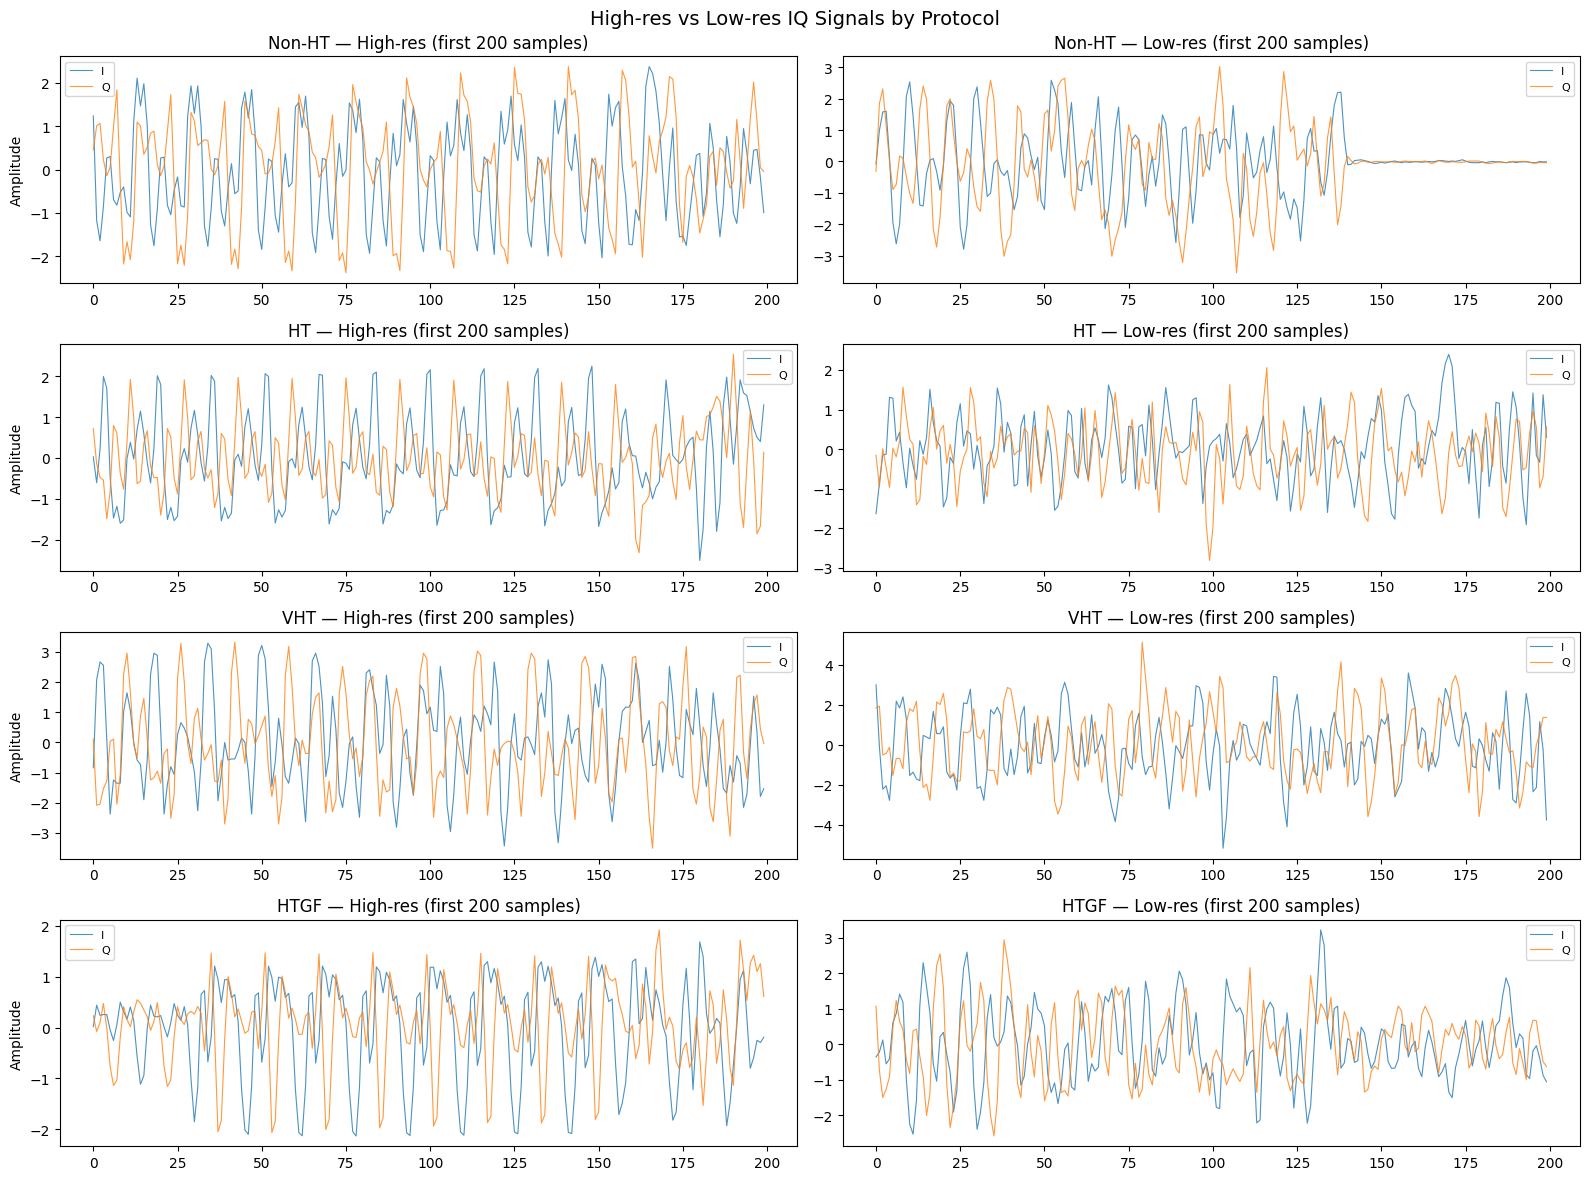

Saved to /workspace/eda_raw_signals.png


In [32]:
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.suptitle('High-res vs Low-res IQ Signals by Protocol', fontsize=14)

for cls in range(4):
    # Find first sample of this class
    idx = (prot_train == cls).nonzero()[0].item()
    
    hi = high_train[idx].numpy()  # (2, 8000)
    lo = low_train[idx].numpy()   # (2, 2000)
    
    # High-res
    ax = axes[cls, 0]
    ax.plot(hi[0, :200], label='I', alpha=0.8, linewidth=0.8)
    ax.plot(hi[1, :200], label='Q', alpha=0.8, linewidth=0.8)
    ax.set_title(f'{PROT_NAMES[cls]} — High-res (first 200 samples)')
    ax.legend(fontsize=8)
    ax.set_ylabel('Amplitude')
    
    # Low-res
    ax = axes[cls, 1]
    ax.plot(lo[0, :200], label='I', alpha=0.8, linewidth=0.8)
    ax.plot(lo[1, :200], label='Q', alpha=0.8, linewidth=0.8)
    ax.set_title(f'{PROT_NAMES[cls]} — Low-res (first 200 samples)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/workspace/eda_raw_signals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /workspace/eda_raw_signals.png")

Raw signal stats:      mean=0.0016, std=0.7072
Filtered signal stats: mean=-0.0010, std=0.5054


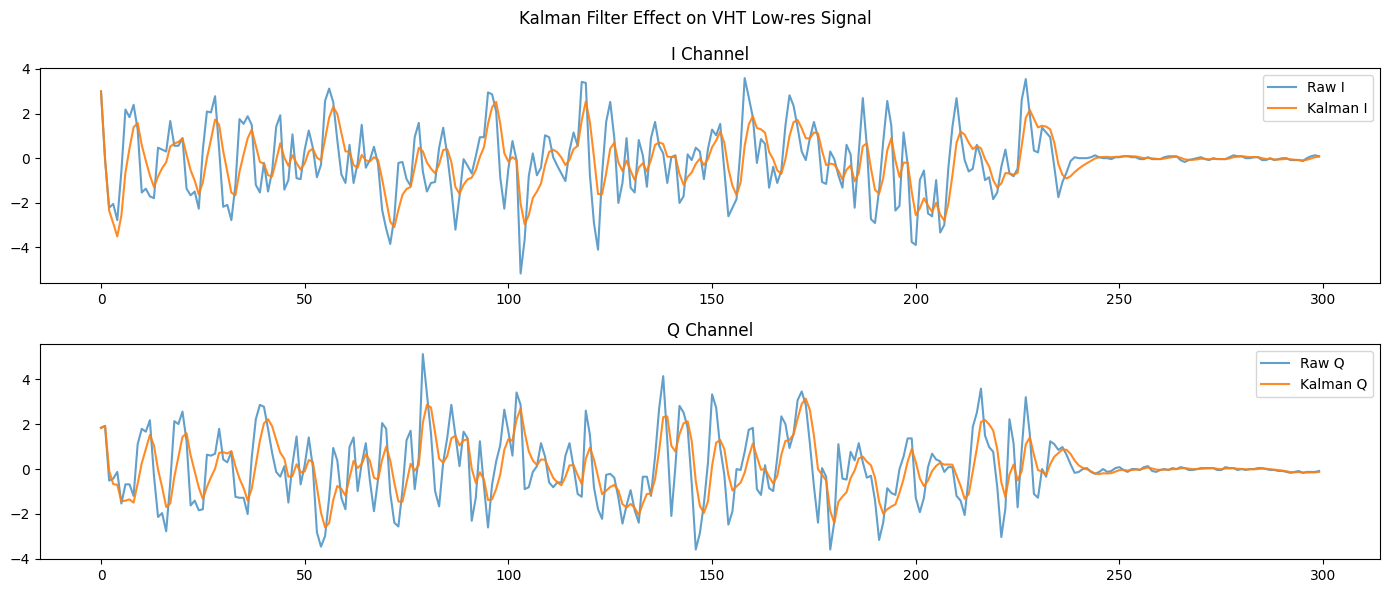

Saved!


In [33]:
def kalman_filter_signal(signal, process_noise=1e-4, measurement_noise=1e-2):
    """
    Apply Kalman filter to IQ signal to smooth and enhance it.
    
    State: [amplitude, velocity]
    Observation: raw amplitude
    
    signal: (2, 2000) tensor — I and Q channels
    returns: (2, 2000) enhanced tensor
    """
    signal_np = signal.numpy()  # (2, 2000)
    output    = np.zeros_like(signal_np)
    
    for ch in range(2):
        x   = signal_np[ch]  # (2000,)
        n   = len(x)
        
        # State transition matrix — constant velocity model
        F = np.array([[1, 1],
                      [0, 1]])
        # Observation matrix — we only observe position
        H = np.array([[1, 0]])
        # Process noise covariance
        Q = process_noise * np.eye(2)
        # Measurement noise covariance
        R = np.array([[measurement_noise]])
        
        # Initialize state and covariance
        state = np.array([x[0], 0.0])
        P     = np.eye(2)
        
        filtered = np.zeros(n)
        
        for t in range(n):
            # Predict
            state = F @ state
            P     = F @ P @ F.T + Q
            
            # Update
            z   = np.array([x[t]])
            y   = z - H @ state
            S   = H @ P @ H.T + R
            K   = P @ H.T @ np.linalg.inv(S)
            state = state + K @ y
            P   = (np.eye(2) - K @ H) @ P
            
            filtered[t] = state[0]
        
        output[ch] = filtered
    
    return torch.tensor(output, dtype=signal.dtype)

# Test on one sample
idx     = (prot_train == 2).nonzero()[0].item()  # VHT sample
raw     = low_train[idx]
filtered = kalman_filter_signal(raw)

print(f"Raw signal stats:      mean={raw.mean():.4f}, std={raw.std():.4f}")
print(f"Filtered signal stats: mean={filtered.mean():.4f}, std={filtered.std():.4f}")

# Quick visual check
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle('Kalman Filter Effect on VHT Low-res Signal')

axes[0].plot(raw[0, :300].numpy(), label='Raw I', alpha=0.7)
axes[0].plot(filtered[0, :300].numpy(), label='Kalman I', alpha=0.9)
axes[0].legend()
axes[0].set_title('I Channel')

axes[1].plot(raw[1, :300].numpy(), label='Raw Q', alpha=0.7)
axes[1].plot(filtered[1, :300].numpy(), label='Kalman Q', alpha=0.9)
axes[1].legend()
axes[1].set_title('Q Channel')

plt.tight_layout()
plt.savefig('/workspace/kalman_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [37]:
!pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 20.4 MB/s  0:00:00m0:00:01


PyWavelets version: 1.8.0
Raw signal stats:      mean=0.0016, std=0.7072
Wavelet signal stats:  mean=0.0016, std=0.6552


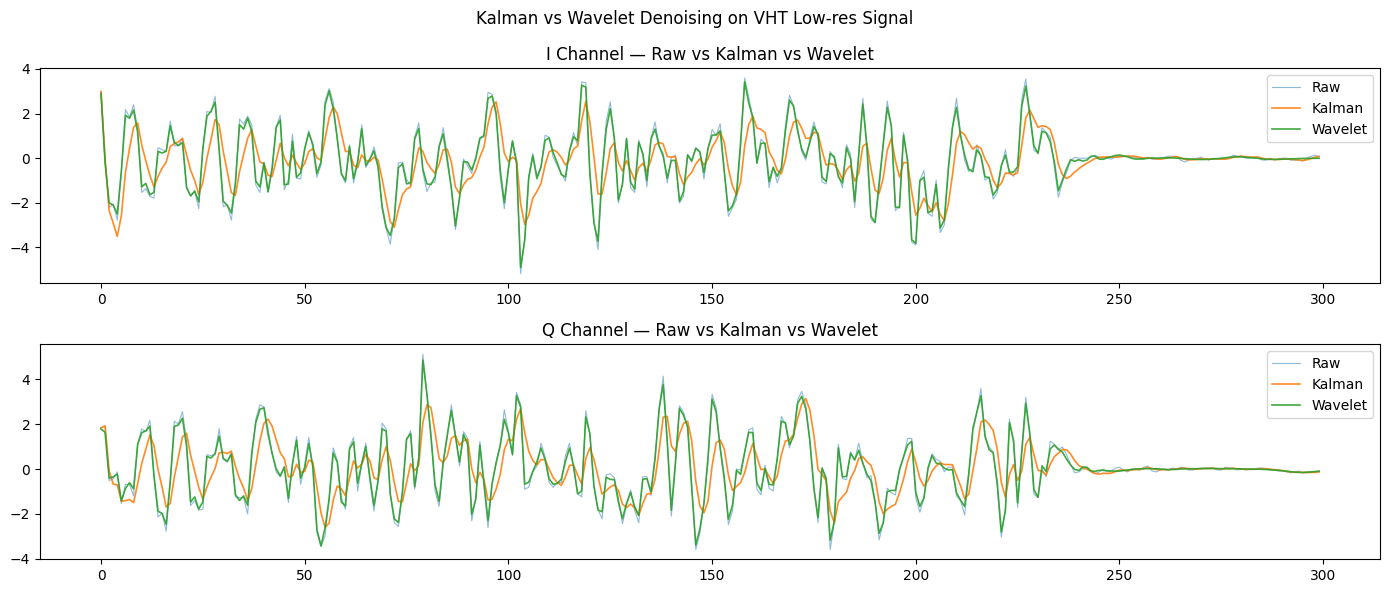

Saved!


In [38]:
import pywt

def wavelet_denoise(signal, wavelet='db4', level=3, threshold_mode='soft'):
    """
    Wavelet denoising on IQ signal.
    Decomposes signal into frequency sub-bands,
    thresholds small coefficients (noise), reconstructs.
    
    signal: (2, 2000) tensor
    returns: (2, 2000) denoised tensor
    """
    signal_np = signal.numpy()
    output    = np.zeros_like(signal_np)
    
    for ch in range(2):
        x = signal_np[ch]
        
        # Decompose
        coeffs = pywt.wavedec(x, wavelet, level=level)
        
        # Estimate noise from finest scale
        sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        
        # Universal threshold
        threshold = sigma * np.sqrt(2 * np.log(len(x)))
        
        # Threshold all detail coefficients (keep approximation)
        coeffs_thresh = [coeffs[0]]  # keep approximation
        for c in coeffs[1:]:
            coeffs_thresh.append(pywt.threshold(c, threshold, mode=threshold_mode))
        
        # Reconstruct
        output[ch] = pywt.waverec(coeffs_thresh, wavelet)[:len(x)]
    
    return torch.tensor(output, dtype=signal.dtype)

# Test — check if pywt is installed
try:
    import pywt
    print(f"PyWavelets version: {pywt.__version__}")
except ImportError:
    print("Installing PyWavelets...")
    os.system("pip install PyWavelets --break-system-packages -q")
    import pywt
    print(f"PyWavelets version: {pywt.__version__}")

# Test on same VHT sample
denoised = wavelet_denoise(raw)

print(f"Raw signal stats:      mean={raw.mean():.4f}, std={raw.std():.4f}")
print(f"Wavelet signal stats:  mean={denoised.mean():.4f}, std={denoised.std():.4f}")

# Compare all three
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle('Kalman vs Wavelet Denoising on VHT Low-res Signal')

axes[0].plot(raw[0, :300].numpy(),      label='Raw',     alpha=0.5, linewidth=0.8)
axes[0].plot(filtered[0, :300].numpy(), label='Kalman',  alpha=0.9, linewidth=1.2)
axes[0].plot(denoised[0, :300].numpy(), label='Wavelet', alpha=0.9, linewidth=1.2)
axes[0].legend()
axes[0].set_title('I Channel — Raw vs Kalman vs Wavelet')

axes[1].plot(raw[1, :300].numpy(),      label='Raw',     alpha=0.5, linewidth=0.8)
axes[1].plot(filtered[1, :300].numpy(), label='Kalman',  alpha=0.9, linewidth=1.2)
axes[1].plot(denoised[1, :300].numpy(), label='Wavelet', alpha=0.9, linewidth=1.2)
axes[1].legend()
axes[1].set_title('Q Channel — Raw vs Kalman vs Wavelet')

plt.tight_layout()
plt.savefig('/workspace/kalman_vs_wavelet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

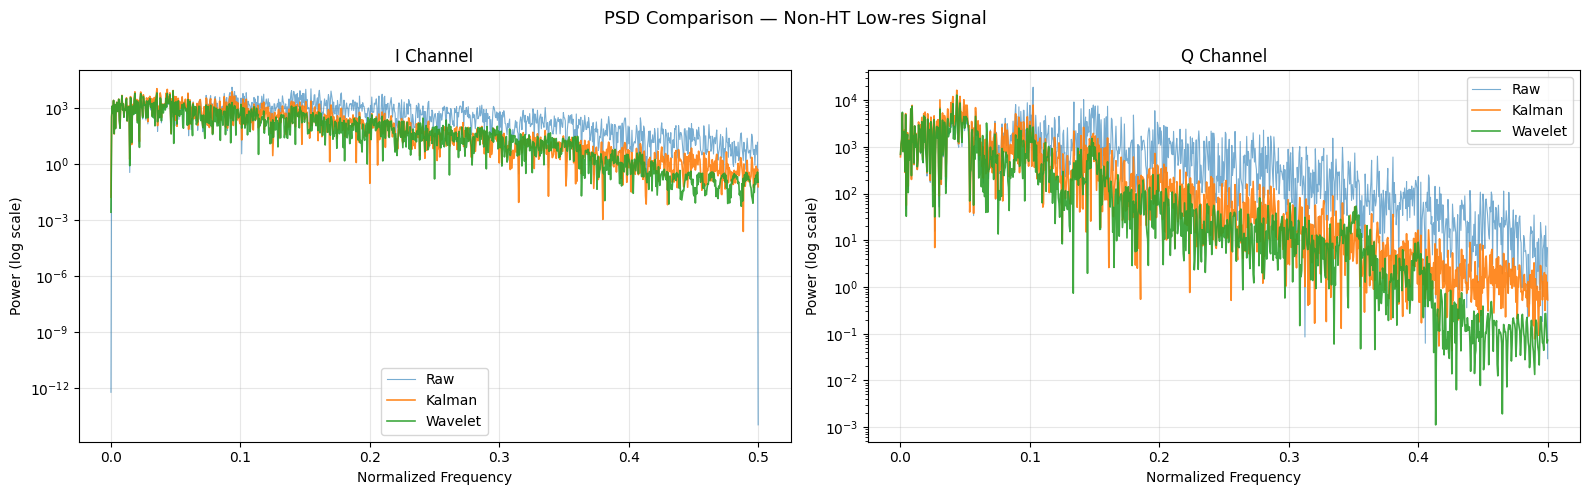

Saved!


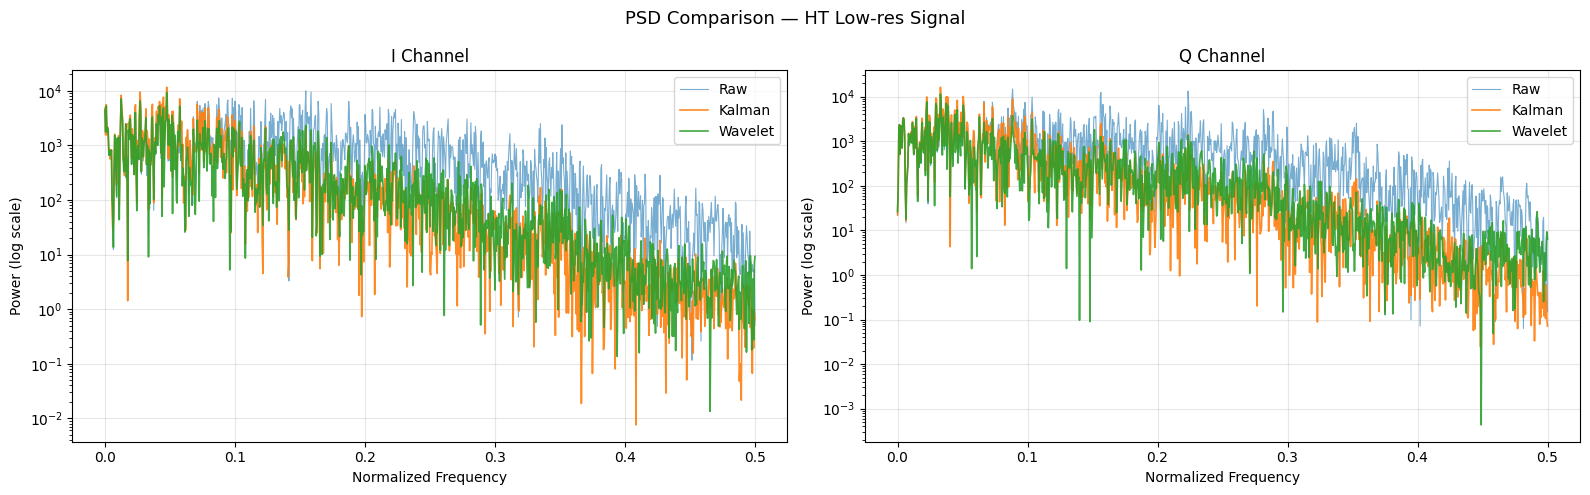

Saved!


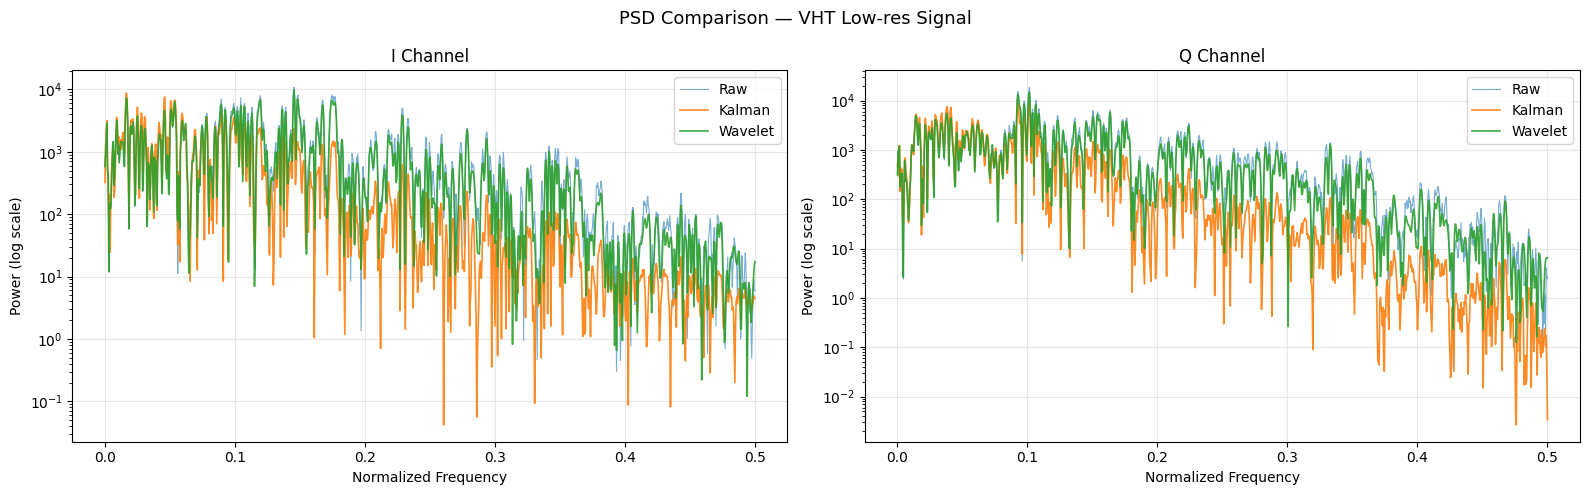

Saved!


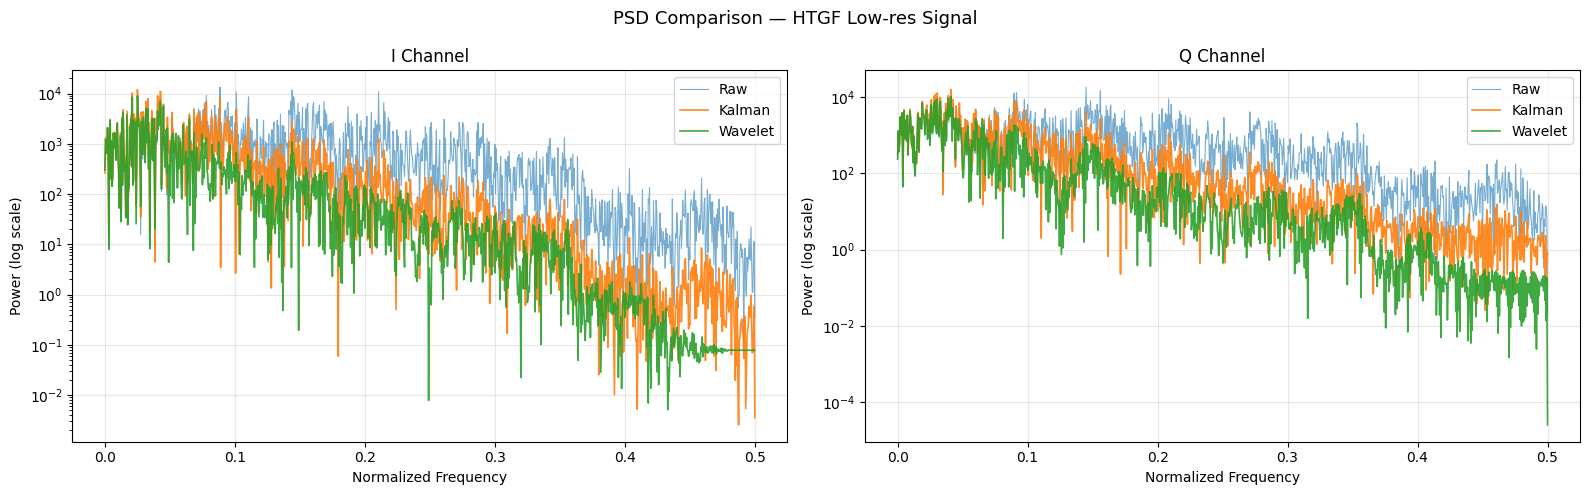

Saved!


In [39]:
def plot_psd_comparison(raw, kalman, wavelet, title='VHT'):
    """
    Power Spectral Density comparison.
    This shows which frequencies each method preserves.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'PSD Comparison — {title} Low-res Signal', fontsize=13)

    for ch_idx, ch_name in enumerate(['I Channel', 'Q Channel']):
        ax  = axes[ch_idx]
        n   = raw.shape[1]
        fs  = 1.0  # normalized frequency

        # Compute PSDs
        raw_np     = raw[ch_idx].numpy()
        kalman_np  = kalman[ch_idx].numpy()
        wavelet_np = wavelet[ch_idx].numpy()

        freqs = np.fft.rfftfreq(n, d=1.0/fs)

        psd_raw     = np.abs(np.fft.rfft(raw_np))**2
        psd_kalman  = np.abs(np.fft.rfft(kalman_np))**2
        psd_wavelet = np.abs(np.fft.rfft(wavelet_np))**2

        ax.semilogy(freqs, psd_raw,     label='Raw',     alpha=0.6, linewidth=0.8)
        ax.semilogy(freqs, psd_kalman,  label='Kalman',  alpha=0.9, linewidth=1.2)
        ax.semilogy(freqs, psd_wavelet, label='Wavelet', alpha=0.9, linewidth=1.2)
        ax.set_xlabel('Normalized Frequency')
        ax.set_ylabel('Power (log scale)')
        ax.set_title(ch_name)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/workspace/psd_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved!")

# Compare PSD for each protocol
for cls in range(4):
    idx      = (prot_train == cls).nonzero()[0].item()
    raw_sig  = low_train[idx]
    kal_sig  = kalman_filter_signal(raw_sig)
    wav_sig  = wavelet_denoise(raw_sig)
    plot_psd_comparison(raw_sig, kal_sig, wav_sig, title=PROT_NAMES[cls])

In [40]:
# Speed check — Kalman is CPU and runs per sample
# This matters because we have 86,437 training samples

import time

# Time single sample
t0 = time.time()
_ = kalman_filter_signal(low_train[0])
print(f"Kalman single sample: {time.time()-t0:.3f}s")

t0 = time.time()
_ = wavelet_denoise(low_train[0])
print(f"Wavelet single sample: {time.time()-t0:.4f}s")

# Estimate total preprocessing time
n_train = len(prot_train)
kalman_time  = (time.time() - t0) * n_train
t0 = time.time()
_ = kalman_filter_signal(low_train[0])
kalman_time = (time.time() - t0) * n_train

print(f"\nEstimated total preprocessing time:")
print(f"Kalman:  {kalman_time/60:.1f} minutes for {n_train:,} samples")

Kalman single sample: 0.048s
Wavelet single sample: 0.0005s

Estimated total preprocessing time:
Kalman:  69.0 minutes for 86,437 samples


In [41]:
import time

t0 = time.time()
_ = kalman_filter_signal(low_train[0])
kalman_time = time.time() - t0

t0 = time.time()
_ = wavelet_denoise(low_train[0])
wavelet_time = time.time() - t0

n = len(prot_train)
print(f"Kalman  per sample: {kalman_time:.4f}s  → total: {kalman_time*n/60:.1f} min")
print(f"Wavelet per sample: {wavelet_time:.4f}s → total: {wavelet_time*n/60:.1f} min")

Kalman  per sample: 0.0492s  → total: 70.8 min
Wavelet per sample: 0.0004s → total: 0.5 min


In [42]:
# Precompute Kalman for all training and test samples
# Run this in background while we train with Wavelet first

print("Precomputing Kalman filtered signals...")
print(f"Estimated time: ~71 minutes")

kalman_low_train = torch.zeros_like(low_train)
kalman_low_test  = torch.zeros_like(low_test)

t0 = time.time()
for i in range(len(low_train)):
    kalman_low_train[i] = kalman_filter_signal(low_train[i])
    if (i+1) % 1000 == 0:
        elapsed = time.time() - t0
        remaining = elapsed / (i+1) * (len(low_train) - i - 1)
        print(f"  {i+1:>6}/{len(low_train)} — {remaining/60:.1f} min remaining")

for i in range(len(low_test)):
    kalman_low_test[i] = kalman_filter_signal(low_test[i])

torch.save({'low_train': kalman_low_train,
            'low_test':  kalman_low_test},
           '/workspace/data/kalman_cache.pt')
print(f"\nDone! Saved to /workspace/data/kalman_cache.pt")
print(f"Total time: {(time.time()-t0)/60:.1f} minutes")

Precomputing Kalman filtered signals...
Estimated time: ~71 minutes
    1000/86437 — 67.9 min remaining
    2000/86437 — 67.0 min remaining
    3000/86437 — 66.1 min remaining
    4000/86437 — 65.5 min remaining
    5000/86437 — 64.8 min remaining
    6000/86437 — 64.1 min remaining
    7000/86437 — 63.4 min remaining
    8000/86437 — 62.7 min remaining
    9000/86437 — 62.0 min remaining
   10000/86437 — 61.3 min remaining
   11000/86437 — 60.5 min remaining
   12000/86437 — 59.9 min remaining
   13000/86437 — 59.1 min remaining
   14000/86437 — 58.3 min remaining
   15000/86437 — 57.5 min remaining
   16000/86437 — 56.6 min remaining
   17000/86437 — 55.8 min remaining
   18000/86437 — 55.0 min remaining
   19000/86437 — 54.2 min remaining
   20000/86437 — 53.4 min remaining
   21000/86437 — 52.7 min remaining
   22000/86437 — 51.9 min remaining
   23000/86437 — 51.1 min remaining
   24000/86437 — 50.4 min remaining
   25000/86437 — 49.6 min remaining
   26000/86437 — 48.8 min remain

In [1]:
import os, time, gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

NUM_PROT = 4
LSIG_LEN = 24
HTSIG_LEN = 48
PROT_NAMES = ["Non-HT", "HT", "VHT", "HTGF"]

train_data = torch.load("/workspace/data/train.pt", map_location="cpu")
test_data  = torch.load("/workspace/data/test.pt", map_location="cpu")

kalman_cache = torch.load("/workspace/data/kalman_cache.pt", map_location="cpu")
kalman_low_train = kalman_cache["low_train"]
kalman_low_test  = kalman_cache["low_test"]

print("Train:", len(kalman_low_train), "| Test:", len(kalman_low_test))
print("Kalman train shape:", kalman_low_train.shape)
print("Kalman test shape:", kalman_low_test.shape)

Device: cuda
GPU: NVIDIA GeForce RTX 5090
Train: 86437 | Test: 9725
Kalman train shape: torch.Size([86437, 2, 2000])
Kalman test shape: torch.Size([9725, 2, 2000])


In [2]:
class KalmanDataset(Dataset):
    def __init__(self, original_data, kalman_low, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = original_data
        self.kalman_low = kalman_low
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        x = self.kalman_low[idx].clone()

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * torch.pi).item()
            c = torch.cos(torch.tensor(theta))
            s = torch.sin(torch.tensor(theta))

            real = x[0].clone()
            imag = x[1].clone()
            x[0] = real * c - imag * s
            x[1] = real * s + imag * c

        return x, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]


kalman_train_ds = KalmanDataset(train_data, kalman_low_train, augment=True)
kalman_test_ds  = KalmanDataset(test_data, kalman_low_test, augment=False)

kalman_train_loader = DataLoader(
    kalman_train_ds,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

kalman_test_loader = DataLoader(
    kalman_test_ds,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [3]:
class KalmanCNN(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.GELU(),

            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256),
            nn.GELU(),

            nn.Conv1d(256, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(embed_dim),
            nn.GELU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.prot_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Linear(128, NUM_PROT)
        )

        self.lsig_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Linear(128, LSIG_LEN)
        )

        self.htsig_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Linear(128, HTSIG_LEN)
        )

    def forward(self, x):
        emb = self.encoder(x).squeeze(-1)
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb

In [4]:
def task_loss_balanced(prot_l, lsig_l, htsig_l, prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0], device=prot_l.device, dtype=prot_l.dtype)

    loss = F.cross_entropy(prot_l, prot_gt.long(), weight=w)
    loss += F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())

    mask = has_htsig.bool()
    if mask.any():
        loss += F.binary_cross_entropy_with_logits(
            htsig_l[mask].float(),
            htsig_gt[mask].float()
        )

    return loss


def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()


def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets.float()).float().mean().item()


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total = 0
    correct = 0
    class_correct = torch.zeros(NUM_PROT)
    class_total = torch.zeros(NUM_PROT)
    total_lsig = 0.0
    n_batches = 0

    for x, prot, lsig, htsig, has_htsig in loader:
        x = x.to(DEVICE, non_blocking=True)
        prot = prot.to(DEVICE, non_blocking=True).long()
        lsig = lsig.to(DEVICE, non_blocking=True).float()

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            prot_l, lsig_l, _, _, _, _ = model(x)

        pred = prot_l.argmax(1)

        correct += (pred == prot).sum().item()
        total += prot.numel()
        total_lsig += bit_acc(lsig_l, lsig)
        n_batches += 1

        for c in range(NUM_PROT):
            mask = prot == c
            class_correct[c] += (pred[mask] == prot[mask]).sum().cpu()
            class_total[c] += mask.sum().cpu()

    overall = correct / total
    lsig_acc = total_lsig / n_batches
    per_class = class_correct / (class_total + 1e-8)

    return overall, lsig_acc, per_class

In [12]:
gc.collect()
torch.cuda.empty_cache()

EPOCHS = 40
LR = 1e-4
SAVE_PATH = "/workspace/kalman_cnn_best.pt"

model = KalmanCNN().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

best_va = 0.0

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\n{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'tr_lsig':>8} {'va_prot':>8} {'va_lsig':>8} {'time':>6}")
print("-" * 70)

for epoch in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()

    total_loss = 0.0
    total_prot = 0.0
    total_lsig = 0.0
    n = 0

    for x, prot, lsig, htsig, has_htsig in kalman_train_loader:
        x = x.to(DEVICE, non_blocking=True)
        prot = prot.to(DEVICE, non_blocking=True).long()
        lsig = lsig.to(DEVICE, non_blocking=True).float()
        htsig = htsig.to(DEVICE, non_blocking=True).float()
        has_htsig = has_htsig.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            prot_l, lsig_l, htsig_l, _, _, _ = model(x)
            loss = task_loss_balanced(prot_l, lsig_l, htsig_l, prot, lsig, htsig, has_htsig)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_prot += prot_acc(prot_l.detach(), prot)
        total_lsig += bit_acc(lsig_l.detach(), lsig)
        n += 1

    va_prot, va_lsig, per_class = evaluate(model, kalman_test_loader)

    if va_prot > best_va:
        best_va = va_prot
        torch.save(model.state_dict(), SAVE_PATH)
        marker = " <- best"
    else:
        marker = ""

    print(
        f"{epoch:3d} {total_loss/n:8.4f} {total_prot/n:8.3f} {total_lsig/n:8.3f} "
        f"{va_prot:8.3f} {va_lsig:8.3f} {time.time()-t0:5.0f}s{marker}",
        flush=True
    )

print(f"\nBest Kalman va_prot: {best_va:.4f}")
print("Saved:", SAVE_PATH)

Parameters: 743,052

 Ep  tr_loss  tr_prot  tr_lsig  va_prot  va_lsig   time
----------------------------------------------------------------------
  1   1.6034    0.728    0.866    0.876    0.884     5s <- best
  2   1.0283    0.881    0.883    0.898    0.886     5s <- best
  3   0.9126    0.920    0.887    0.889    0.891     5s
  4   0.8648    0.933    0.890    0.918    0.893     5s <- best
  5   0.8327    0.940    0.893    0.916    0.896     5s
  6   0.8121    0.944    0.896    0.882    0.900     5s
  7   0.7909    0.947    0.899    0.934    0.898     5s <- best
  8   0.7759    0.950    0.904    0.933    0.903     5s
  9   0.7515    0.953    0.908    0.900    0.911     5s
 10   0.7353    0.954    0.912    0.923    0.914     5s
 11   0.7143    0.954    0.916    0.911    0.918     5s
 12   0.6897    0.957    0.920    0.926    0.921     5s
 13   0.6668    0.960    0.924    0.908    0.924     5s
 14   0.6505    0.960    0.927    0.929    0.925     5s
 15   0.6354    0.961    0.930    0.

In [13]:
model.load_state_dict(torch.load("/workspace/kalman_cnn_best.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

overall, lsig_acc, per_class = evaluate(model, kalman_test_loader)

print(f"Overall Kalman: {overall:.4f}")
print(f"L-SIG Kalman:   {lsig_acc:.4f}")
print("\nPer-class accuracy:")

for name, acc in zip(PROT_NAMES, per_class):
    print(f"{name:>8}: {acc.item()*100:.1f}%")

Overall Kalman: 0.9406
L-SIG Kalman:   0.9430

Per-class accuracy:
  Non-HT: 96.1%
      HT: 91.7%
     VHT: 55.8%
    HTGF: 100.0%


In [14]:
STFT_SWEEPS = [
    {"name": "stft_64_16",  "n_fft": 64,  "hop": 16, "lr": 1e-4},
    {"name": "stft_128_16", "n_fft": 128, "hop": 16, "lr": 1e-4},
    {"name": "stft_256_32", "n_fft": 256, "hop": 32, "lr": 1e-4},
]

In [22]:
def train_stft_config(cfg, epochs=20):
    gc.collect()
    torch.cuda.empty_cache()

    model = STFTModel(
        n_fft=cfg["n_fft"],
        hop_length=cfg["hop"],
        embed_dim=512
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=1e-4
    )

    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

    save_path = f"/workspace/{cfg['name']}_best_overall.pt"
    best_vht_path = f"/workspace/{cfg['name']}_best_vht_valid.pt"

    best_va = 0.0
    best_valid_vht = 0.0
    best_per_class = None

    print(f"\nRunning {cfg['name']} | n_fft={cfg['n_fft']} hop={cfg['hop']} lr={cfg['lr']}")
    print(
        f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'va_prot':>8} "
        f"{'NonHT':>7} {'HT':>7} {'VHT':>7} {'HTGF':>7} "
        f"{'predVHT':>8} {'fake?':>7} {'time':>6}"
    )
    print("-" * 95)

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()

        total_loss = 0.0
        total_prot = 0.0
        n = 0

        for high_iq, low_iq, prot, lsig, htsig, has_htsig in train_loader:
            x = low_iq.to(DEVICE, non_blocking=True)
            prot = prot.to(DEVICE, non_blocking=True).long()
            lsig = lsig.to(DEVICE, non_blocking=True).float()
            htsig = htsig.to(DEVICE, non_blocking=True).float()
            has_htsig = has_htsig.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                prot_l, lsig_l, htsig_l, _, _, _ = model(x)
                loss = task_loss_balanced(
                    prot_l, lsig_l, htsig_l,
                    prot, lsig, htsig, has_htsig
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            total_prot += prot_acc(prot_l.detach(), prot)
            n += 1

        va_prot, va_lsig, per_class, cm, pred_dist = evaluate_stft_full(model, test_loader)

        nonht = per_class[0].item() * 100
        ht = per_class[1].item() * 100
        vht = per_class[2].item() * 100
        htgf = per_class[3].item() * 100

        pred_vht = pred_dist[2].item() * 100

        # fake VHT spike detector:
        # VHT looks high, but overall is bad or model predicts too many VHT samples.
        fake_vht = (vht >= 65 and va_prot < 0.93) or (pred_vht > 10.0)

        marker = ""

        if va_prot > best_va:
            best_va = va_prot
            best_per_class = per_class.clone()
            torch.save(model.state_dict(), save_path)
            marker += " <- best overall"

        # Save best VHT only if overall is still reasonable
        if vht > best_valid_vht and va_prot >= 0.94 and ht >= 88 and nonht >= 95:
            best_valid_vht = vht
            torch.save(model.state_dict(), best_vht_path)
            marker += " <- best valid VHT"

        key = f"{cfg['name']}_epoch_{epoch}"
        all_confusions[key] = cm.clone().cpu()

        all_epoch_rows.append({
            "config": cfg["name"],
            "epoch": epoch,
            "tr_loss": total_loss / n,
            "tr_prot": total_prot / n,
            "va_prot": va_prot,
            "va_lsig": va_lsig,
            "nonht": nonht,
            "ht": ht,
            "vht": vht,
            "htgf": htgf,
            "pred_nonht": pred_dist[0].item() * 100,
            "pred_ht": pred_dist[1].item() * 100,
            "pred_vht": pred_vht,
            "pred_htgf": pred_dist[3].item() * 100,
            "fake_vht_spike": fake_vht,
            "overall_path": save_path,
            "valid_vht_path": best_vht_path,
        })

        print(
            f"{epoch:3d} {total_loss/n:8.4f} {total_prot/n:8.3f} {va_prot:8.3f} "
            f"{nonht:7.1f} {ht:7.1f} {vht:7.1f} {htgf:7.1f} "
            f"{pred_vht:8.1f} {str(fake_vht):>7} {time.time()-t0:5.0f}s{marker}",
            flush=True
        )

        if epoch == 8 and va_prot < 0.93:
            print("Stopping early — weak config.")
            break

    print(f"\nBest overall {cfg['name']}: {best_va:.4f}")
    print(f"Best valid VHT {cfg['name']}: {best_valid_vht:.1f}%")

    if best_per_class is not None:
        for name, acc in zip(PROT_NAMES, best_per_class):
            print(f"{name:>8}: {acc.item()*100:.1f}%")

    return {
        "name": cfg["name"],
        "best_va": best_va,
        "best_valid_vht": best_valid_vht,
        "per_class": best_per_class,
        "save_path": save_path,
        "best_vht_path": best_vht_path,
    }

In [24]:
!pip install pandas

  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)


In [25]:
import pandas as pd

all_epoch_rows = []
all_confusions = {}

@torch.no_grad()
def evaluate_stft_full(model, loader, return_cm=True):
    model.eval()

    total = 0
    correct = 0

    class_correct = torch.zeros(NUM_PROT)
    class_total = torch.zeros(NUM_PROT)

    pred_total = torch.zeros(NUM_PROT)

    cm = torch.zeros(NUM_PROT, NUM_PROT, dtype=torch.long)

    total_lsig = 0.0
    n_batches = 0

    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        x = low_iq.to(DEVICE, non_blocking=True)
        y = prot.to(DEVICE, non_blocking=True).long()
        lsig = lsig.to(DEVICE, non_blocking=True).float()

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            prot_l, lsig_l, _, _, _, _ = model(x)

        pred = prot_l.argmax(1)

        correct += (pred == y).sum().item()
        total += y.numel()
        total_lsig += bit_acc(lsig_l, lsig)
        n_batches += 1

        for c in range(NUM_PROT):
            true_mask = y == c
            pred_mask = pred == c

            class_correct[c] += (pred[true_mask] == y[true_mask]).sum().cpu()
            class_total[c] += true_mask.sum().cpu()
            pred_total[c] += pred_mask.sum().cpu()

        for t, p in zip(y.cpu(), pred.cpu()):
            cm[t, p] += 1

    overall = correct / total
    lsig_acc = total_lsig / n_batches
    per_class = class_correct / (class_total + 1e-8)
    pred_dist = pred_total / pred_total.sum()

    return overall, lsig_acc, per_class, cm, pred_dist

In [21]:
key = "stft_64_16_epoch_6"
cm = all_confusions[key]

print("Rows=true, cols=pred")
print(cm)

for i, name in enumerate(PROT_NAMES):
    row = cm[i]
    print(name, row.tolist(), "acc:", row[i].item() / max(1, row.sum().item()))


Running stft_64_16 | n_fft=64 hop=16 lr=0.0001
 Ep  tr_loss  tr_prot  va_prot      VHT   time
-------------------------------------------------------
  1   1.2830    0.828    0.903     29.4    23s <- best
  2   0.8093    0.953    0.917     70.4    19s <- best
  3   0.7084    0.972    0.946     57.1    19s <- best
  4   0.6313    0.978    0.946     53.4    19s <- best
  5   0.5583    0.982    0.948     57.7    19s <- best
  6   0.4931    0.983    0.867     80.3    19s
  7   0.4566    0.985    0.930     74.7    20s
  8   0.4295    0.985    0.948     56.3    19s <- best
  9   0.4060    0.986    0.933     69.3    19s
 10   0.3874    0.986    0.926     69.5    20s
 11   0.3682    0.986    0.947     49.6    20s
 12   0.3529    0.987    0.918     59.3    20s
 13   0.3352    0.987    0.725     93.5    20s
 14   0.3218    0.988    0.910     73.0    20s
 15   0.3055    0.988    0.944     55.5    19s


KeyboardInterrupt: 

In [ ]:
df = pd.DataFrame(all_epoch_rows)

display(df.sort_values("va_prot", ascending=False).head(15))

print("Best balanced epochs:")
display(
    df[
        (df["va_prot"] >= 0.95) &
        (df["vht"] >= 55) &
        (df["ht"] >= 90) &
        (df["nonht"] >= 96) &
        (df["fake_vht_spike"] == False)
    ].sort_values(["va_prot", "vht"], ascending=False)
)

print("Fake VHT spike epochs:")
display(
    df[df["fake_vht_spike"] == True]
    .sort_values("vht", ascending=False)
)

In [18]:
# ============================================================
# FULL SETUP CELL
# ============================================================

import os, gc, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# -------------------------
# Seeds
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

# -------------------------
# Constants
# -------------------------
EMBED_DIM = 512
NUM_PROT = 4
LSIG_LEN = 24
HTSIG_LEN = 48

PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

# -------------------------
# Load Data
# -------------------------
print("Loading data...")

train_data = torch.load("/workspace/data/train.pt")
test_data  = torch.load("/workspace/data/test.pt")

print("Loaded.")

# ============================================================
# DATASET
# ============================================================

class AugmentedDataset(Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment

    def __len__(self):
        return len(self.prot)

    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()

        if self.augment:
            theta = torch.empty(1).uniform_(0, 2*np.pi).item()

            cos_t = torch.cos(torch.tensor(theta))
            sin_t = torch.sin(torch.tensor(theta))

            for iq in (high, low):
                real = iq[0].clone()

                iq[0] = real * cos_t - iq[1] * sin_t
                iq[1] = real * sin_t + iq[1] * cos_t

        return (
            high,
            low,
            self.prot[idx],
            self.lsig[idx],
            self.htsig[idx],
            self.has_htsig[idx]
        )

# ============================================================
# DATA LOADERS
# ============================================================

train_ds = AugmentedDataset(train_data, augment=True)
test_ds  = AugmentedDataset(test_data, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train:", len(train_ds))
print("Test :", len(test_ds))

# ============================================================
# METRICS
# ============================================================

def prot_acc(logits, targets):
    preds = logits.argmax(1)
    return (preds == targets).float().mean().item()

def bit_acc(logits, targets):
    preds = (torch.sigmoid(logits) > 0.5).float()
    return (preds == targets).float().mean().item()

# ============================================================
# LOSS FUNCTION
# ============================================================

def task_loss_balanced(
    prot_l,
    lsig_l,
    htsig_l,
    prot_gt,
    lsig_gt,
    htsig_gt,
    has_htsig
):
    weights = torch.tensor(
        [0.5, 1.5, 8.0, 8.0],
        device=prot_l.device,
        dtype=prot_l.dtype
    )

    loss = F.cross_entropy(prot_l, prot_gt, weight=weights)

    loss += F.binary_cross_entropy_with_logits(
        lsig_l.float(),
        lsig_gt.float()
    )

    mask = has_htsig.bool()

    if mask.any():
        loss += F.binary_cross_entropy_with_logits(
            htsig_l[mask].float(),
            htsig_gt[mask].float()
        )

    return loss

# ============================================================
# LR Scheduler
# ============================================================

def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):

    def lr_lambda(epoch):

        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs

        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)

        return 0.5 * (
            1 + np.cos(np.pi * progress)
        )

    return torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda
    )

print("All dependencies ready.")

Device: cuda
GPU: NVIDIA GeForce RTX 5090
Loading data...
Loaded.
Train: 86437
Test : 9725
All dependencies ready.


In [27]:
import gc, time
import pandas as pd
import torch

all_epoch_rows = []
all_confusions = {}

STFT_SWEEPS = [
    {"name": "stft_64_16",  "n_fft": 64,  "hop": 16, "lr": 1e-4},
    {"name": "stft_128_16", "n_fft": 128, "hop": 16, "lr": 1e-4},
    {"name": "stft_256_32", "n_fft": 256, "hop": 32, "lr": 1e-4},
]

@torch.no_grad()
def evaluate_stft_full(model, loader):
    model.eval()

    total = 0
    correct = 0

    class_correct = torch.zeros(NUM_PROT)
    class_total = torch.zeros(NUM_PROT)
    pred_total = torch.zeros(NUM_PROT)

    cm = torch.zeros(NUM_PROT, NUM_PROT, dtype=torch.long)

    total_lsig = 0.0
    n_batches = 0

    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        x = low_iq.to(DEVICE, non_blocking=True)
        y = prot.to(DEVICE, non_blocking=True).long()
        lsig = lsig.to(DEVICE, non_blocking=True).float()

        with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
            prot_l, lsig_l, _, _, _, _ = model(x)

        pred = prot_l.argmax(1)

        correct += (pred == y).sum().item()
        total += y.numel()
        total_lsig += bit_acc(lsig_l, lsig)
        n_batches += 1

        for c in range(NUM_PROT):
            true_mask = y == c
            pred_mask = pred == c

            class_correct[c] += (pred[true_mask] == y[true_mask]).sum().cpu()
            class_total[c] += true_mask.sum().cpu()
            pred_total[c] += pred_mask.sum().cpu()

        for t, p in zip(y.cpu(), pred.cpu()):
            cm[t, p] += 1

    overall = correct / total
    lsig_acc = total_lsig / n_batches
    per_class = class_correct / (class_total + 1e-8)
    pred_dist = pred_total / pred_total.sum()

    return overall, lsig_acc, per_class, cm, pred_dist


def train_stft_config(cfg, epochs=20):
    gc.collect()
    torch.cuda.empty_cache()

    model = STFTModel(
        n_fft=cfg["n_fft"],
        hop_length=cfg["hop"],
        embed_dim=512
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=1e-4
    )

    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

    save_path = f"/workspace/{cfg['name']}_best_overall.pt"
    best_vht_path = f"/workspace/{cfg['name']}_best_valid_vht.pt"

    best_va = 0.0
    best_valid_vht = 0.0
    best_per_class = None

    print(f"\nRunning {cfg['name']} | n_fft={cfg['n_fft']} hop={cfg['hop']} lr={cfg['lr']}")
    print(
        f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'va_prot':>8} "
        f"{'NonHT':>7} {'HT':>7} {'VHT':>7} {'HTGF':>7} "
        f"{'predVHT':>8} {'fake?':>7} {'time':>6}"
    )
    print("-" * 100)

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()

        total_loss = 0.0
        total_prot = 0.0
        n = 0

        for high_iq, low_iq, prot, lsig, htsig, has_htsig in train_loader:
            x = low_iq.to(DEVICE, non_blocking=True)
            prot = prot.to(DEVICE, non_blocking=True).long()
            lsig = lsig.to(DEVICE, non_blocking=True).float()
            htsig = htsig.to(DEVICE, non_blocking=True).float()
            has_htsig = has_htsig.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                prot_l, lsig_l, htsig_l, _, _, _ = model(x)

                loss = task_loss_balanced(
                    prot_l,
                    lsig_l,
                    htsig_l,
                    prot,
                    lsig,
                    htsig,
                    has_htsig
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            total_prot += prot_acc(prot_l.detach(), prot)
            n += 1

        va_prot, va_lsig, per_class, cm, pred_dist = evaluate_stft_full(model, test_loader)

        nonht = per_class[0].item() * 100
        ht    = per_class[1].item() * 100
        vht   = per_class[2].item() * 100
        htgf  = per_class[3].item() * 100

        pred_nonht = pred_dist[0].item() * 100
        pred_ht    = pred_dist[1].item() * 100
        pred_vht   = pred_dist[2].item() * 100
        pred_htgf  = pred_dist[3].item() * 100

        # Fake VHT spike detector:
        # VHT accuracy looks high, but overall accuracy is bad or model predicts too many VHT.
        fake_vht = (
            (vht >= 65 and va_prot < 0.93)
            or pred_vht > 10.0
            or ht < 80
            or nonht < 90
        )

        marker = ""

        if va_prot > best_va:
            best_va = va_prot
            best_per_class = per_class.clone()
            torch.save(model.state_dict(), save_path)
            marker += " <- best overall"

        # Save VHT checkpoint only if it is not fake and overall is still usable.
        if (
            vht > best_valid_vht
            and va_prot >= 0.94
            and nonht >= 95
            and ht >= 88
            and not fake_vht
        ):
            best_valid_vht = vht
            torch.save(model.state_dict(), best_vht_path)
            marker += " <- best valid VHT"

        key = f"{cfg['name']}_epoch_{epoch}"
        all_confusions[key] = cm.clone().cpu()

        all_epoch_rows.append({
            "config": cfg["name"],
            "epoch": epoch,
            "tr_loss": total_loss / n,
            "tr_prot": total_prot / n,
            "va_prot": va_prot,
            "va_lsig": va_lsig,

            "nonht": nonht,
            "ht": ht,
            "vht": vht,
            "htgf": htgf,

            "pred_nonht": pred_nonht,
            "pred_ht": pred_ht,
            "pred_vht": pred_vht,
            "pred_htgf": pred_htgf,

            "fake_vht_spike": fake_vht,
            "confusion_key": key,
            "best_overall_path": save_path,
            "best_valid_vht_path": best_vht_path,
        })

        print(
            f"{epoch:3d} {total_loss/n:8.4f} {total_prot/n:8.3f} {va_prot:8.3f} "
            f"{nonht:7.1f} {ht:7.1f} {vht:7.1f} {htgf:7.1f} "
            f"{pred_vht:8.1f} {str(fake_vht):>7} {time.time()-t0:5.0f}s{marker}",
            flush=True
        )

        if epoch == 8 and va_prot < 0.93:
            print("Stopping early — weak config.")
            break

    print(f"\nBest overall {cfg['name']}: {best_va:.4f}")
    print(f"Best valid VHT {cfg['name']}: {best_valid_vht:.1f}%")

    if best_per_class is not None:
        for name, acc in zip(PROT_NAMES, best_per_class):
            print(f"{name:>8}: {acc.item()*100:.1f}%")

    return {
        "name": cfg["name"],
        "best_va": best_va,
        "best_valid_vht": best_valid_vht,
        "per_class": best_per_class,
        "save_path": save_path,
        "best_vht_path": best_vht_path,
    }


stft_results = []

for cfg in STFT_SWEEPS:
    result = train_stft_config(cfg, epochs=20)
    stft_results.append(result)

df = pd.DataFrame(all_epoch_rows)

print("\nFinal STFT sweep results:")
for r in stft_results:
    print(r["name"], r["best_va"], r["best_valid_vht"], r["save_path"], r["best_vht_path"])

print("\nTop epochs by overall:")
display(df.sort_values("va_prot", ascending=False).head(15))

print("\nBest balanced epochs:")
display(
    df[
        (df["va_prot"] >= 0.95) &
        (df["vht"] >= 55) &
        (df["ht"] >= 90) &
        (df["nonht"] >= 96) &
        (df["fake_vht_spike"] == False)
    ].sort_values(["va_prot", "vht"], ascending=False)
)

print("\nFake VHT spike epochs:")
display(
    df[df["fake_vht_spike"] == True]
    .sort_values("vht", ascending=False)
)


Running stft_64_16 | n_fft=64 hop=16 lr=0.0001
 Ep  tr_loss  tr_prot  va_prot   NonHT      HT     VHT    HTGF  predVHT   fake?   time
----------------------------------------------------------------------------------------------------
  1   1.2475    0.857    0.921    96.3    73.5    52.3     0.0      5.0    True    19s <- best overall
  2   0.8183    0.952    0.943    96.7    89.7    52.3     0.0      4.0   False    19s <- best overall <- best valid VHT
  3   0.7220    0.971    0.948    98.0    87.2    46.4     0.0      3.1   False    19s <- best overall
  4   0.6482    0.978    0.947    97.1    89.4    55.8     0.0      4.1   False    19s <- best valid VHT
 11   0.3839    0.986    0.949    96.9    92.4    57.1    50.0      4.2   False    20s <- best valid VHT
 12   0.3693    0.986    0.949    97.0    92.6    55.8     0.0      4.0   False    19s
 13   0.3522    0.986    0.947    96.9    90.8    58.0   100.0      4.3   False    20s <- best valid VHT
 14   0.3364    0.987    0.948    9

,config,epoch,tr_loss,tr_prot,va_prot,va_lsig,nonht,ht,vht,htgf,pred_nonht,pred_ht,pred_vht,pred_htgf,fake_vht_spike,confusion_key,best_overall_path,best_valid_vht_path
32,stft_256_32,5,0.584116,0.978365,0.950951,0.929057,97.231627,92.222220,56.334233,0.0,85.161954,10.889460,3.948586,0.000000,False,stft_256_32_epoch_5,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
4,stft_64_16,5,0.572920,0.981619,0.950231,0.930197,97.703093,89.907408,50.673854,0.0,86.035991,10.550129,3.413882,0.000000,False,stft_64_16_epoch_5,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
19,stft_64_16,20,0.256767,0.990003,0.949820,0.942434,97.304159,92.222220,51.752019,0.0,85.336763,11.012854,3.650386,0.000000,False,stft_64_16_epoch_20,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
7,stft_64_16,8,0.437570,0.984895,0.949717,0.944881,97.195357,91.574073,55.795151,0.0,85.213369,10.755784,4.000000,0.030848,False,stft_64_16_epoch_8,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
11,stft_64_16,12,0.369346,0.986120,0.949409,0.940377,97.026110,92.592591,55.795151,0.0,84.935731,10.982005,4.010283,0.071979,False,stft_64_16_epoch_12,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
36,stft_256_32,9,0.452924,0.983843,0.949306,0.947979,97.086555,91.666669,56.873316,0.0,85.059124,10.838046,4.102828,0.000000,False,stft_256_32_epoch_9,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
10,stft_64_16,11,0.383912,0.986109,0.948997,0.946982,96.929401,92.407405,57.142860,50.0,84.832907,10.920309,4.164524,0.082262,False,stft_64_16_epoch_11,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
39,stft_256_32,12,0.408048,0.985103,0.948895,0.952648,96.929401,92.407405,57.142860,0.0,84.812337,10.992288,4.185090,0.010283,False,stft_256_32_epoch_12,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
5,stft_64_16,6,0.506598,0.982699,0.948792,0.941676,96.977758,92.129630,56.603771,0.0,84.925449,11.002570,4.071980,0.000000,False,stft_64_16_epoch_6,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
16,stft_64_16,17,0.294284,0.988189,0.948586,0.952889,97.811896,87.592590,50.673854,0.0,86.385602,10.190231,3.424165,0.000000,False,stft_64_16_epoch_17,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt



Best balanced epochs:


,config,epoch,tr_loss,tr_prot,va_prot,va_lsig,nonht,ht,vht,htgf,pred_nonht,pred_ht,pred_vht,pred_htgf,fake_vht_spike,confusion_key,best_overall_path,best_valid_vht_path
32,stft_256_32,5,0.584116,0.978365,0.950951,0.929057,97.231627,92.22222,56.334233,0.0,85.161954,10.88946,3.948586,0.0,False,stft_256_32_epoch_5,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt



Fake VHT spike epochs:


,config,epoch,tr_loss,tr_prot,va_prot,va_lsig,nonht,ht,vht,htgf,pred_nonht,pred_ht,pred_vht,pred_htgf,fake_vht_spike,confusion_key,best_overall_path,best_valid_vht_path
9,stft_64_16,10,0.398482,0.985745,0.733162,0.941030,69.922632,92.129630,94.339621,50.0,60.000002,13.778920,26.190230,0.030848,True,stft_64_16_epoch_10,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
18,stft_64_16,19,0.269265,0.989559,0.553213,0.927278,50.108802,82.407409,92.991912,0.0,43.208227,9.953728,46.817482,0.020566,True,stft_64_16_epoch_19,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
43,stft_256_32,16,0.357257,0.985450,0.877841,0.954391,87.463731,91.666669,84.097034,0.0,75.455010,11.825193,12.719794,0.000000,True,stft_256_32_epoch_16,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
30,stft_256_32,3,0.722060,0.965676,0.820874,0.918306,86.835104,46.018520,81.671160,0.0,75.321335,5.254499,19.424164,0.000000,True,stft_256_32_epoch_3,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
20,stft_128_16,1,1.312073,0.833294,0.840823,0.886337,83.752418,89.166665,77.088946,0.0,72.565556,16.051415,11.383034,0.000000,True,stft_128_16_epoch_1,/workspace/stft_128_16_best_overall.pt,/workspace/stft_128_16_best_valid_vht.pt
44,stft_256_32,17,0.349206,0.985606,0.919280,0.957090,92.831236,90.462965,76.280326,50.0,80.544984,10.457584,8.915167,0.082262,True,stft_256_32_epoch_17,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
31,stft_256_32,4,0.651556,0.973604,0.881542,0.927030,90.933269,71.111113,76.280326,0.0,79.341900,8.164524,12.493573,0.000000,True,stft_256_32_epoch_4,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
15,stft_64_16,16,0.308945,0.987923,0.910437,0.944877,91.767406,93.240738,68.733156,50.0,79.784060,13.501285,6.694087,0.020566,True,stft_64_16_epoch_16,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
42,stft_256_32,15,0.371482,0.985785,0.872596,0.949326,87.826401,94.074076,55.256063,0.0,76.637530,18.910025,4.401028,0.051414,True,stft_256_32_epoch_15,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
26,stft_128_16,7,0.500690,0.982376,0.929357,0.933727,97.437137,71.666664,54.986525,0.0,87.681234,8.318766,4.000000,0.000000,True,stft_128_16_epoch_7,/workspace/stft_128_16_best_overall.pt,/workspace/stft_128_16_best_valid_vht.pt


In [28]:
# ============================================================
# Analyze STFT sweep + choose winners + define next fine sweep
# ============================================================

import os
import pandas as pd

OUT_DIR = "/workspace/final_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.DataFrame(all_epoch_rows)

# Save raw epoch history
df.to_csv(f"{OUT_DIR}/stft_epoch_history.csv", index=False)

print("=== TOP OVERALL EPOCHS ===")
display(
    df.sort_values("va_prot", ascending=False)
      [["config", "epoch", "va_prot", "nonht", "ht", "vht", "htgf", "pred_vht", "fake_vht_spike", "best_overall_path", "best_valid_vht_path"]]
      .head(15)
)

print("\n=== TOP VALID VHT EPOCHS ===")
valid_vht = df[
    (df["fake_vht_spike"] == False) &
    (df["va_prot"] >= 0.93) &
    (df["nonht"] >= 95) &
    (df["ht"] >= 85)
].sort_values("vht", ascending=False)

display(
    valid_vht[["config", "epoch", "va_prot", "nonht", "ht", "vht", "htgf", "pred_vht", "best_valid_vht_path"]]
    .head(15)
)

print("\n=== BEST BALANCED EPOCHS ===")
balanced = df[
    (df["fake_vht_spike"] == False) &
    (df["va_prot"] >= 0.945) &
    (df["vht"] >= 55) &
    (df["ht"] >= 90) &
    (df["nonht"] >= 96)
].sort_values(["va_prot", "vht"], ascending=False)

display(
    balanced[["config", "epoch", "va_prot", "nonht", "ht", "vht", "htgf", "pred_vht"]]
)

print("\n=== FAKE VHT SPIKES ===")
display(
    df[df["fake_vht_spike"] == True]
    .sort_values("vht", ascending=False)
    [["config", "epoch", "va_prot", "nonht", "ht", "vht", "htgf", "pred_vht"]]
)

# Pick winners
best_overall = df.sort_values("va_prot", ascending=False).iloc[0]
best_vht = valid_vht.iloc[0] if len(valid_vht) else None
best_balanced = balanced.iloc[0] if len(balanced) else None

summary_rows = []

summary_rows.append({
    "winner_type": "best_overall",
    "config": best_overall["config"],
    "epoch": int(best_overall["epoch"]),
    "overall": best_overall["va_prot"] * 100,
    "nonht": best_overall["nonht"],
    "ht": best_overall["ht"],
    "vht": best_overall["vht"],
    "htgf": best_overall["htgf"],
    "pred_vht": best_overall["pred_vht"],
})

if best_vht is not None:
    summary_rows.append({
        "winner_type": "best_valid_vht",
        "config": best_vht["config"],
        "epoch": int(best_vht["epoch"]),
        "overall": best_vht["va_prot"] * 100,
        "nonht": best_vht["nonht"],
        "ht": best_vht["ht"],
        "vht": best_vht["vht"],
        "htgf": best_vht["htgf"],
        "pred_vht": best_vht["pred_vht"],
    })

if best_balanced is not None:
    summary_rows.append({
        "winner_type": "best_balanced",
        "config": best_balanced["config"],
        "epoch": int(best_balanced["epoch"]),
        "overall": best_balanced["va_prot"] * 100,
        "nonht": best_balanced["nonht"],
        "ht": best_balanced["ht"],
        "vht": best_balanced["vht"],
        "htgf": best_balanced["htgf"],
        "pred_vht": best_balanced["pred_vht"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{OUT_DIR}/stft_winners_summary.csv", index=False)

print("\n=== WINNER SUMMARY ===")
display(summary_df)

# Save confusion matrices for winner epochs
cm_dir = f"{OUT_DIR}/confusions"
os.makedirs(cm_dir, exist_ok=True)

for _, row in summary_df.iterrows():
    key = f"{row['config']}_epoch_{int(row['epoch'])}"
    if key in all_confusions:
        cm = all_confusions[key]
        cm_df = pd.DataFrame(cm.numpy(), index=PROT_NAMES, columns=PROT_NAMES)
        cm_df.to_csv(f"{cm_dir}/{row['winner_type']}_{key}.csv")
        print(f"\nConfusion matrix: {row['winner_type']} | {key}")
        display(cm_df)

# Suggested next fine sweep around best VHT/time-resolution winner
print("\n=== NEXT FINE SWEEP TO RUN ===")

NEXT_STFT_SWEEPS = [
    {"name": "stft_48_8",   "n_fft": 48,  "hop": 8,  "lr": 1e-4},
    {"name": "stft_48_12",  "n_fft": 48,  "hop": 12, "lr": 1e-4},
    {"name": "stft_64_8",   "n_fft": 64,  "hop": 8,  "lr": 1e-4},
    {"name": "stft_64_12",  "n_fft": 64,  "hop": 12, "lr": 1e-4},
    {"name": "stft_80_16",  "n_fft": 80,  "hop": 16, "lr": 1e-4},
]

display(pd.DataFrame(NEXT_STFT_SWEEPS))

print("""
Interpretation:
- Use best_overall if you want headline accuracy.
- Use best_valid_vht if you want minority-class/VHT story.
- Use best_balanced if you want the cleanest paper checkpoint.
- Next run should fine-sweep around n_fft=48/64/80 and hop=8/12/16.
""")

=== TOP OVERALL EPOCHS ===


,config,epoch,va_prot,nonht,ht,vht,htgf,pred_vht,fake_vht_spike,best_overall_path,best_valid_vht_path
32,stft_256_32,5,0.950951,97.231627,92.222220,56.334233,0.0,3.948586,False,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
4,stft_64_16,5,0.950231,97.703093,89.907408,50.673854,0.0,3.413882,False,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
19,stft_64_16,20,0.949820,97.304159,92.222220,51.752019,0.0,3.650386,False,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
7,stft_64_16,8,0.949717,97.195357,91.574073,55.795151,0.0,4.000000,False,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
11,stft_64_16,12,0.949409,97.026110,92.592591,55.795151,0.0,4.010283,False,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
36,stft_256_32,9,0.949306,97.086555,91.666669,56.873316,0.0,4.102828,False,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
10,stft_64_16,11,0.948997,96.929401,92.407405,57.142860,50.0,4.164524,False,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
39,stft_256_32,12,0.948895,96.929401,92.407405,57.142860,0.0,4.185090,False,/workspace/stft_256_32_best_overall.pt,/workspace/stft_256_32_best_valid_vht.pt
5,stft_64_16,6,0.948792,96.977758,92.129630,56.603771,0.0,4.071980,False,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt
16,stft_64_16,17,0.948586,97.811896,87.592590,50.673854,0.0,3.424165,False,/workspace/stft_64_16_best_overall.pt,/workspace/stft_64_16_best_valid_vht.pt



=== TOP VALID VHT EPOCHS ===


,config,epoch,va_prot,nonht,ht,vht,htgf,pred_vht,best_valid_vht_path
47,stft_256_32,20,0.938612,95.502901,91.203701,65.229112,50.0,5.984576,/workspace/stft_256_32_best_valid_vht.pt
13,stft_64_16,14,0.947763,96.929401,90.462965,59.568733,50.0,4.359897,/workspace/stft_64_16_best_valid_vht.pt
14,stft_64_16,15,0.938098,95.490813,93.055558,59.029651,0.0,4.668380,/workspace/stft_64_16_best_valid_vht.pt
25,stft_128_16,6,0.937789,95.563346,92.222220,59.029651,0.0,4.802056,/workspace/stft_128_16_best_valid_vht.pt
22,stft_128_16,3,0.935527,95.418280,91.388887,58.760107,0.0,4.750643,/workspace/stft_128_16_best_valid_vht.pt
38,stft_256_32,11,0.947352,96.711797,92.314816,58.221024,0.0,4.658098,/workspace/stft_256_32_best_valid_vht.pt
12,stft_64_16,13,0.947352,96.893132,90.833336,57.951480,100.0,4.349614,/workspace/stft_64_16_best_valid_vht.pt
40,stft_256_32,13,0.943753,96.965665,87.222224,57.951480,0.0,4.514139,/workspace/stft_256_32_best_valid_vht.pt
23,stft_128_16,4,0.938406,96.470022,86.203706,57.951480,0.0,4.709512,/workspace/stft_128_16_best_valid_vht.pt
39,stft_256_32,12,0.948895,96.929401,92.407405,57.142860,0.0,4.185090,/workspace/stft_256_32_best_valid_vht.pt



=== BEST BALANCED EPOCHS ===


...


Confusion matrix: best_balanced | stft_256_32_epoch_5


,Non-HT,HT,VHT,HTGF
Non-HT,8043,59,170,0
HT,79,996,5,0
VHT,158,4,209,0
HTGF,2,0,0,0



=== NEXT FINE SWEEP TO RUN ===


,name,n_fft,hop,lr
0,stft_48_8,48,8,0.0001
1,stft_48_12,48,12,0.0001
2,stft_64_8,64,8,0.0001
3,stft_64_12,64,12,0.0001
4,stft_80_16,80,16,0.0001



Interpretation:
- Use best_overall if you want headline accuracy.
- Use best_valid_vht if you want minority-class/VHT story.
- Use best_balanced if you want the cleanest paper checkpoint.
- Next run should fine-sweep around n_fft=48/64/80 and hop=8/12/16.



In [2]:
# ============================================================
# STFT FINE SWEEP — continued
# ============================================================

import os, gc, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

NUM_PROT = 4; LSIG_LEN = 24; HTSIG_LEN = 48
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

# ── Load data ────────────────────────────────────────────────
train_data = torch.load("/workspace/data/train.pt")
test_data  = torch.load("/workspace/data/test.pt")
high_train, low_train, prot_train, lsig_train, htsig_train, has_htsig_train = train_data
high_test,  low_test,  prot_test,  lsig_test,  htsig_test,  has_htsig_test  = test_data
print(f"Train: {len(prot_train):,} | Test: {len(prot_test):,}")

# ── Helpers ──────────────────────────────────────────────────
def task_loss_balanced(prot_l, lsig_l, htsig_l, prot_gt, lsig_gt, htsig_gt, has_htsig):
    w = torch.tensor([0.5, 1.5, 8.0, 8.0], device=prot_l.device, dtype=prot_l.dtype)
    loss = F.cross_entropy(prot_l, prot_gt, weight=w)
    loss += F.binary_cross_entropy_with_logits(lsig_l.float(), lsig_gt.float())
    mask = has_htsig.bool()
    if mask.any():
        loss += F.binary_cross_entropy_with_logits(htsig_l[mask].float(), htsig_gt[mask].float())
    return loss

def bit_acc(logits, targets):
    return ((logits.sigmoid() > 0.5).float() == targets.float()).float().mean().item()

def prot_acc(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def get_scheduler_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Dataset ──────────────────────────────────────────────────
class AugmentedDataset(Dataset):
    def __init__(self, data, augment=False):
        self.high, self.low, self.prot, self.lsig, self.htsig, self.has_htsig = data
        self.augment = augment
    def __len__(self): return len(self.prot)
    def __getitem__(self, idx):
        high = self.high[idx].clone()
        low  = self.low[idx].clone()
        if self.augment:
            theta = torch.empty(1).uniform_(0, 2 * np.pi).item()
            c, s  = np.cos(theta), np.sin(theta)
            for iq in (high, low):
                real = iq[0].clone()
                iq[0] = real * c - iq[1] * s
                iq[1] = real * s + iq[1] * c
        return high, low, self.prot[idx], self.lsig[idx], self.htsig[idx], self.has_htsig[idx]

train_ds = AugmentedDataset(train_data, augment=True)
test_ds  = AugmentedDataset(test_data,  augment=False)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

# ── STFTModel ────────────────────────────────────────────────
class STFTModel(nn.Module):
    def __init__(self, n_fft=128, hop_length=32, embed_dim=512):
        super().__init__()
        self.n_fft = n_fft
        self.hop_length = hop_length

        self.cnn = nn.Sequential(
            nn.Conv2d(2, 32,  kernel_size=3, padding=1), nn.BatchNorm2d(32),  nn.GELU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),  nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256, embed_dim, kernel_size=3, padding=1), nn.BatchNorm2d(embed_dim), nn.GELU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.prot_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, NUM_PROT))
        self.lsig_head  = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, LSIG_LEN))
        self.htsig_head = nn.Sequential(nn.Linear(embed_dim, 128), nn.GELU(), nn.Linear(128, HTSIG_LEN))

    def compute_stft(self, x):
        B = x.shape[0]
        window = torch.hann_window(self.n_fft).to(x.device)
        specs = []
        for ch in range(2):
            signal = x[:, ch, :]
            spec_batch = []
            for b in range(B):
                stft = torch.stft(signal[b], n_fft=self.n_fft,
                                  hop_length=self.hop_length,
                                  window=window, return_complex=True)
                spec_batch.append(torch.abs(stft))
            specs.append(torch.stack(spec_batch))
        return torch.stack(specs, dim=1)

    def forward(self, x):
        spec = self.compute_stft(x)
        emb  = self.cnn(spec).squeeze(-1).squeeze(-1)
        return self.prot_head(emb), self.lsig_head(emb), self.htsig_head(emb), emb, emb, emb

# ── Evaluation with full per-class stats ─────────────────────
@torch.no_grad()
def evaluate_full(model, loader):
    model.eval()
    correct = tot = 0
    class_correct = torch.zeros(NUM_PROT)
    class_total   = torch.zeros(NUM_PROT)
    pred_total    = torch.zeros(NUM_PROT)
    cm = torch.zeros(NUM_PROT, NUM_PROT, dtype=torch.long)
    tot_lsig = n_batches = 0

    for high_iq, low_iq, prot, lsig, htsig, has_htsig in loader:
        x    = low_iq.to(DEVICE)
        y    = prot.to(DEVICE).long()
        lsig = lsig.to(DEVICE).float()
        with torch.amp.autocast('cuda'):
            prot_l, lsig_l, _, _, _, _ = model(x)
        pred = prot_l.argmax(1)
        correct += (pred == y).sum().item()
        tot     += y.numel()
        tot_lsig += bit_acc(lsig_l, lsig)
        n_batches += 1
        for c in range(NUM_PROT):
            tm = y == c; pm = pred == c
            class_correct[c] += (pred[tm] == y[tm]).sum().cpu()
            class_total[c]   += tm.sum().cpu()
            pred_total[c]    += pm.sum().cpu()
        for t, p in zip(y.cpu(), pred.cpu()):
            cm[t, p] += 1

    overall   = correct / tot
    per_class = class_correct / (class_total + 1e-8)
    pred_dist = pred_total / pred_total.sum()
    return overall, tot_lsig / n_batches, per_class, cm, pred_dist

# ── Fake VHT spike detector ───────────────────────────────────
def is_fake(vht, overall, nonht, ht, pred_vht):
    return (
        (vht >= 65 and overall < 0.93)
        or pred_vht > 10.0
        or ht < 80
        or nonht < 90
    )

# ── Training function ─────────────────────────────────────────
all_epoch_rows = []
all_confusions = {}

def train_stft_config(cfg, epochs=40):
    gc.collect(); torch.cuda.empty_cache()

    model = STFTModel(n_fft=cfg["n_fft"], hop_length=cfg["hop"], embed_dim=512).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    scaler    = torch.amp.GradScaler('cuda')

    save_path     = f"/workspace/{cfg['name']}_best_overall.pt"
    best_vht_path = f"/workspace/{cfg['name']}_best_valid_vht.pt"
    best_va = best_valid_vht = 0.0
    best_per_class = None

    print(f"\n{'='*100}")
    print(f"Running {cfg['name']} | n_fft={cfg['n_fft']} hop={cfg['hop']} lr={cfg['lr']} epochs={epochs}")
    print(f"{'Ep':>3} {'tr_loss':>8} {'tr_prot':>8} {'va_prot':>8} "
          f"{'NonHT':>7} {'HT':>7} {'VHT':>7} {'HTGF':>7} "
          f"{'predVHT':>8} {'fake?':>7} {'time':>6}")
    print("-" * 100)

    for epoch in range(1, epochs + 1):
        model.train()
        t0 = time.time()
        tot_loss = tot_prot = n = 0

        for high_iq, low_iq, prot, lsig, htsig, has_htsig in train_loader:
            x         = low_iq.to(DEVICE)
            prot      = prot.to(DEVICE).long()
            lsig      = lsig.to(DEVICE).float()
            htsig     = htsig.to(DEVICE).float()
            has_htsig = has_htsig.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                prot_l, lsig_l, htsig_l, _, _, _ = model(x)
                loss = task_loss_balanced(prot_l, lsig_l, htsig_l, prot, lsig, htsig, has_htsig)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()

            tot_loss += loss.item()
            tot_prot += prot_acc(prot_l.detach(), prot)
            n += 1

        va_prot, va_lsig, per_class, cm, pred_dist = evaluate_full(model, test_loader)
        nonht    = per_class[0].item() * 100
        ht       = per_class[1].item() * 100
        vht      = per_class[2].item() * 100
        htgf     = per_class[3].item() * 100
        pred_vht = pred_dist[2].item() * 100
        fake     = is_fake(vht, va_prot, nonht, ht, pred_vht)

        marker = ""
        if va_prot > best_va:
            best_va = va_prot
            best_per_class = per_class.clone()
            torch.save(model.state_dict(), save_path)
            marker += " <- best overall"
        if vht > best_valid_vht and va_prot >= 0.93 and nonht >= 95 and ht >= 88 and not fake:
            best_valid_vht = vht
            torch.save(model.state_dict(), best_vht_path)
            marker += " <- best valid VHT"

        key = f"{cfg['name']}_epoch_{epoch}"
        all_confusions[key] = cm.clone().cpu()
        all_epoch_rows.append({
            "config": cfg["name"], "epoch": epoch,
            "tr_loss": tot_loss/n, "tr_prot": tot_prot/n,
            "va_prot": va_prot, "va_lsig": va_lsig,
            "nonht": nonht, "ht": ht, "vht": vht, "htgf": htgf,
            "pred_vht": pred_vht, "fake_vht_spike": fake,
            "best_overall_path": save_path, "best_valid_vht_path": best_vht_path,
        })

        print(f"{epoch:3d} {tot_loss/n:8.4f} {tot_prot/n:8.3f} {va_prot:8.3f} "
              f"{nonht:7.1f} {ht:7.1f} {vht:7.1f} {htgf:7.1f} "
              f"{pred_vht:8.1f} {str(fake):>7} {time.time()-t0:5.0f}s{marker}", flush=True)

        # Early stop if clearly weak at epoch 10
        if epoch == 10 and va_prot < 0.92:
            print("Stopping early — weak config."); break

    print(f"\nBest overall {cfg['name']}: {best_va:.4f}")
    print(f"Best valid VHT {cfg['name']}: {best_valid_vht:.1f}%")
    if best_per_class is not None:
        for name, acc in zip(PROT_NAMES, best_per_class):
            print(f"  {name:>8}: {acc.item()*100:.1f}%")

    return {"name": cfg["name"], "best_va": best_va, "best_valid_vht": best_valid_vht,
            "per_class": best_per_class, "save_path": save_path, "best_vht_path": best_vht_path}

# ── Sweep configs ─────────────────────────────────────────────
FINE_SWEEP = [
    # Priority 1: extend the winner to 80 epochs
    {"name": "stft_256_32_long",  "n_fft": 256, "hop": 32, "lr": 1e-4},
    # Priority 2: different hop sizes around the winning n_fft=256
    {"name": "stft_256_16",       "n_fft": 256, "hop": 16, "lr": 1e-4},
    {"name": "stft_256_48",       "n_fft": 256, "hop": 48, "lr": 1e-4},
    # Priority 3: smaller n_fft (more time resolution, less frequency resolution)
    {"name": "stft_64_8",         "n_fft": 64,  "hop": 8,  "lr": 1e-4},
    {"name": "stft_64_12",        "n_fft": 64,  "hop": 12, "lr": 1e-4},
    {"name": "stft_80_16",        "n_fft": 80,  "hop": 16, "lr": 1e-4},
    {"name": "stft_48_8",         "n_fft": 48,  "hop": 8,  "lr": 1e-4},
    {"name": "stft_48_12",        "n_fft": 48,  "hop": 12, "lr": 1e-4},
]

# ── Run sweep ─────────────────────────────────────────────────
stft_results = []
for cfg in FINE_SWEEP:
    epochs = 80 if "long" in cfg["name"] else 40
    result = train_stft_config(cfg, epochs=epochs)
    stft_results.append(result)

# ── Summary ───────────────────────────────────────────────────
df = pd.DataFrame(all_epoch_rows)
os.makedirs("/workspace/final_analysis", exist_ok=True)
df.to_csv("/workspace/final_analysis/stft_fine_sweep_history.csv", index=False)

print("\n\n=== FINE SWEEP SUMMARY ===")
for r in sorted(stft_results, key=lambda x: x["best_valid_vht"], reverse=True):
    print(f"{r['name']:25s} | overall: {r['best_va']*100:.2f}% | valid VHT: {r['best_valid_vht']:.1f}%")

print("\n=== TOP VALID VHT EPOCHS ===")
valid = df[
    (df["fake_vht_spike"] == False) &
    (df["va_prot"] >= 0.93) &
    (df["nonht"] >= 95) &
    (df["ht"] >= 88)
].sort_values("vht", ascending=False)
print(valid[["config", "epoch", "va_prot", "nonht", "ht", "vht", "htgf", "pred_vht"]].head(20).to_string())

Train: 86,437 | Test: 9,725

Running stft_256_32_long | n_fft=256 hop=32 lr=0.0001 epochs=80
 Ep  tr_loss  tr_prot  va_prot   NonHT      HT     VHT    HTGF  predVHT   fake?   time
----------------------------------------------------------------------------------------------------
  1   1.2468    0.861    0.925    96.7    75.0    49.9     0.0      5.0    True    26s <- best overall
  2   0.8474    0.947    0.879    89.1    83.8    73.9     0.0     11.1    True    21s
  3   0.7345    0.963    0.940    97.1    83.7    55.8     0.0      4.5   False    22s <- best overall
  4   0.6508    0.971    0.924    97.5    68.1    51.2     0.0      3.9    True    21s
  5   0.5841    0.977    0.940    96.8    85.2    58.2     0.0      4.8   False    21s <- best overall
  6   0.5405    0.979    0.933    94.8    93.7    58.5     0.0      4.4   False    21s
  7   0.5089    0.981    0.938    95.6    92.9    56.6     0.0      4.2   False    22s <- best valid VHT
  8   0.4816    0.981    0.935    97.2    77

In [5]:
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os

os.makedirs('/workspace/paper_figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

train_data = torch.load('/workspace/data/train.pt')
high_train = train_data[0]
low_train  = train_data[1]
prot_train = train_data[2]

# Use a VHT sample
vht_idx = (prot_train == 2).nonzero()[0].item()
hi = high_train[vht_idx]  # (2, 8000)
lo = low_train[vht_idx]   # (2, 2000)

def compute_stft(signal, n_fft=80, hop=16):
    x = torch.tensor(signal).float()
    window = torch.hann_window(n_fft)
    stft = torch.stft(x, n_fft=n_fft, hop_length=hop,
                      window=window, return_complex=True)
    return torch.abs(stft).numpy()

fig, axes = plt.subplots(2, 3, figsize=(7, 4))
fig.suptitle('Effect of 4$\\times$ Downsampling on VHT Signal',
             fontsize=9, fontweight='bold')

SHOW = 300

# ── Row 1: Raw IQ signal ─────────────────────────────────────
ax = axes[0, 0]
ax.plot(hi[0, :SHOW].numpy(), linewidth=0.7, color='#4878CF', label='I')
ax.plot(hi[1, :SHOW].numpy(), linewidth=0.7, color='#D65F5F',
        alpha=0.7, label='Q')
ax.set_title('High-res IQ (8,000 samples)')
ax.set_ylabel('Amplitude')
ax.set_xlabel('Sample index')
ax.legend(fontsize=7, loc='upper right')
ax.grid(alpha=0.2)

ax = axes[0, 1]
ax.plot(lo[0, :SHOW].numpy(), linewidth=0.7, color='#4878CF', label='I')
ax.plot(lo[1, :SHOW].numpy(), linewidth=0.7, color='#D65F5F',
        alpha=0.7, label='Q')
ax.set_title('Low-res IQ (2,000 samples)')
ax.set_xlabel('Sample index')
ax.legend(fontsize=7, loc='upper right')
ax.grid(alpha=0.2)

# ── PSD comparison ───────────────────────────────────────────
ax = axes[0, 2]
N_AVG = 30
psds_hi, psds_lo = [], []
for idx in (prot_train == 2).nonzero().squeeze()[:N_AVG]:
    s_hi = high_train[idx][0].numpy()
    s_lo = low_train[idx][0].numpy()
    psds_hi.append(np.abs(np.fft.rfft(s_hi))**2)
    psds_lo.append(np.abs(np.fft.rfft(s_lo))**2)

f_hi = np.fft.rfftfreq(8000)
f_lo = np.fft.rfftfreq(2000)
ax.semilogy(f_hi, np.mean(psds_hi, axis=0),
            color='#4878CF', linewidth=1.0, label='High-res')
ax.semilogy(f_lo, np.mean(psds_lo, axis=0),
            color='#D65F5F', linewidth=1.0, linestyle='--',
            label='Low-res')
ax.axvline(x=0.25, color='black', linewidth=1.5,
           linestyle='-', label='Nyquist cutoff')
ax.axvspan(0.25, 0.5, alpha=0.10, color='red')
ax.set_title('VHT Power Spectral Density')
ax.set_xlabel('Normalized frequency')
ax.set_ylabel('PSD')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.text(0.37, ax.get_ylim()[0] * 3,
        'Destroyed\nband', fontsize=7, color='red', ha='center')

# ── Row 2: Spectrograms ──────────────────────────────────────
ax = axes[1, 0]
mag_hi = compute_stft(hi[0].numpy(), n_fft=80, hop=40)
im = ax.imshow(mag_hi, aspect='auto', origin='lower',
               cmap='inferno',
               norm=LogNorm(vmin=1e-3, vmax=mag_hi.max()))
ax.set_title('High-res spectrogram')
ax.set_xlabel('Time frame')
ax.set_ylabel('Frequency bin')

ax = axes[1, 1]
mag_lo = compute_stft(lo[0].numpy(), n_fft=80, hop=16)
im2 = ax.imshow(mag_lo, aspect='auto', origin='lower',
                cmap='inferno',
                norm=LogNorm(vmin=1e-3, vmax=mag_hi.max()))
ax.set_title('Low-res spectrogram')
ax.set_xlabel('Time frame')

ax = axes[1, 2]
ax.axis('off')
ax.text(0.5, 0.6,
        'The discriminative\nspectral band\n(freq $>$ 0.25)\nis eliminated\nby downsampling.\n\n'
        'No model can\nrecover information\nthat was never\nsampled.',
        transform=ax.transAxes,
        ha='center', va='center', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='#FFF3E0',
                  alpha=0.9, pad=0.5))

plt.tight_layout()
plt.savefig('/workspace/paper_figures/fig_data_limitation.pdf')
plt.savefig('/workspace/paper_figures/fig_data_limitation.png')
plt.close()
print("Saved.")

Saved.


In [6]:
import torch
train_data = torch.load('/workspace/data/train.pt')
high_train = train_data[0]
low_train  = train_data[1]
print("High-res shape:", high_train[0].shape)
print("Low-res shape:", low_train[0].shape)

High-res shape: torch.Size([2, 8000])
Low-res shape: torch.Size([2, 2000])


In [7]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

os.makedirs('/workspace/paper_figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

t_hi  = np.linspace(0, 1e-6 * 200, 10000)
t_lo  = np.linspace(0, 1e-6 * 200, 2500)

f_true  = 1.8e6
f_alias = 0.55e6
f_low   = 0.3e6

sig_true  = np.sin(2 * np.pi * f_true  * t_hi)
sig_low   = np.sin(2 * np.pi * f_low   * t_hi)
sig_alias = np.sin(2 * np.pi * f_alias * t_lo)
sig_clean = np.sin(2 * np.pi * f_low   * t_lo)

fig, axes = plt.subplots(2, 2, figsize=(7, 4))
fig.suptitle('Aliasing: Why the Anti-Aliasing Filter is Necessary',
             fontsize=9, fontweight='bold')

# ── Top left: original high-freq signal ──────────────────────
ax = axes[0, 0]
ax.plot(t_hi * 1e6, sig_true, color='#4878CF', linewidth=0.8)
ax.set_title('Original signal (1.8 MHz)')
ax.set_xlabel('Time ($\\mu$s)')
ax.set_ylabel('Amplitude')
ax.grid(alpha=0.3)
ax.text(0.05, 0.85, 'Above Nyquist limit',
        transform=ax.transAxes, fontsize=7,
        color='red', fontweight='bold')

# ── Top right: low-freq signal we want ───────────────────────
ax = axes[0, 1]
ax.plot(t_hi * 1e6, sig_low, color='#6ACC65', linewidth=0.8)
ax.set_title('Low-frequency component we want (0.3 MHz)')
ax.set_xlabel('Time ($\\mu$s)')
ax.grid(alpha=0.3)

# ── Bottom left: without filter — aliased signal ─────────────
ax = axes[1, 0]
ax.plot(t_lo * 1e6, sig_clean + sig_alias,
        color='#D65F5F', linewidth=0.8,
        label='Corrupted signal')
ax.plot(t_lo * 1e6, sig_clean,
        color='#6ACC65', linewidth=0.8,
        linestyle='--', alpha=0.6,
        label='True signal')
ax.set_title('Without anti-aliasing filter')
ax.set_xlabel('Time ($\\mu$s)')
ax.set_ylabel('Amplitude')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.text(0.05, 0.85,
        '1.8 MHz folds to 0.55 MHz\ncorrupting the signal',
        transform=ax.transAxes, fontsize=7, color='red')

# ── Bottom right: with filter — clean signal ─────────────────
ax = axes[1, 1]
ax.plot(t_lo * 1e6, sig_clean,
        color='#6ACC65', linewidth=0.8,
        label='Clean signal')
ax.set_title('With anti-aliasing filter')
ax.set_xlabel('Time ($\\mu$s)')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.text(0.05, 0.85,
        '1.8 MHz removed before\nsampling — no corruption',
        transform=ax.transAxes, fontsize=7, color='#2E7D32')

plt.tight_layout()
plt.savefig('/workspace/paper_figures/fig_aliasing.pdf')
plt.savefig('/workspace/paper_figures/fig_aliasing.png')
plt.close()
print("Saved.")

Saved.


In [11]:
import torch
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

os.makedirs('/workspace/paper_figures', exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

train_data = torch.load('/workspace/data/train.pt')
prot_train = train_data[2]

PROT_NAMES  = ['Non-HT', 'HT', 'VHT', 'HT-GF']
PROT_COLORS = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']
WEIGHTS     = [0.5, 1.5, 8.0, 8.0]

counts = [(prot_train == i).sum().item() for i in range(4)]
total  = sum(counts)
pcts   = [c / total * 100 for c in counts]

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
fig.suptitle('Class Imbalance and Assigned Loss Weights',
             fontsize=9, fontweight='bold')

# ── Left: class distribution ─────────────────────────────────
ax = axes[0]
bars = ax.bar(PROT_NAMES, counts, color=PROT_COLORS,
              edgecolor='white', width=0.6)
ax.set_yscale('log')
ax.set_ylabel('Number of training samples (log scale)')
ax.set_title('Training set class distribution')
ax.grid(axis='y', alpha=0.3)

for bar, count, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.3,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=7)

# ── Right: assigned weights ───────────────────────────────────
ax = axes[1]
bars = ax.bar(PROT_NAMES, WEIGHTS, color=PROT_COLORS,
              edgecolor='white', width=0.6)
ax.set_ylabel('Cross-entropy loss weight')
ax.set_title('Assigned class weights')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 10)

for bar, w in zip(bars, WEIGHTS):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f'{w}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold')

# annotate the inverse relationship
ax.text(0.5, 0.92,
        'Weights are inversely proportional to class frequency',
        transform=ax.transAxes, ha='center',
        fontsize=7, style='italic', color='gray')

plt.tight_layout()
plt.savefig('/workspace/paper_figures/fig_class_dist.pdf')
plt.savefig('/workspace/paper_figures/fig_class_dist.png')
plt.close()
print("Saved.")

Saved.


In [14]:
import os
from PIL import Image

# Create output folder
os.makedirs('/workspace/paper_figures', exist_ok=True)

figures = ['protocol_dist', 'iq_signals', 'psd', 'tsne']

for f in figures:
    src = f'/workspace/{f}.png'
    dst = f'/workspace/paper_figures/{f}.pdf'
    
    if os.path.exists(src):
        img = Image.open(src)

        # Convert RGBA -> RGB if needed
        if img.mode in ('RGBA', 'LA', 'P'):
            img = img.convert('RGB')

        img.save(dst, "PDF", resolution=300.0)
        print(f'Converted {f}.png → paper_figures/{f}.pdf')
    else:
        print(f'NOT FOUND: {src}')

print('\nDone. Files in paper_figures:')
for f in os.listdir('/workspace/paper_figures'):
    print(' ', f)

Converted protocol_dist.png → paper_figures/protocol_dist.pdf
Converted iq_signals.png → paper_figures/iq_signals.pdf
Converted psd.png → paper_figures/psd.pdf
Converted tsne.png → paper_figures/tsne.pdf

Done. Files in paper_figures:
  tsne.pdf
  psd.pdf
  iq_signals.pdf
  protocol_dist.pdf
  fig_class_dist.png
  fig_class_dist.pdf
  fig_aliasing.png
  fig_aliasing.pdf
  fig_data_limitation.png
  fig_data_limitation.pdf
  .ipynb_checkpoints
  fig_ceiling.png
  fig_ceiling.pdf


In [16]:
from PIL import Image
import os

os.makedirs('/workspace/paper_figures', exist_ok=True)

src = '/workspace/constellation.png'
dst = '/workspace/paper_figures/constellation.pdf'

img = Image.open(src)

# Convert transparency/palette modes if needed
if img.mode in ('RGBA', 'LA', 'P'):
    img = img.convert('RGB')

img.save(dst, "PDF", resolution=300.0)

print("Done:", dst)

Done: /workspace/paper_figures/constellation.pdf


In [19]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np

N_SAMPLE = 2000
idx_sample = np.random.RandomState(42).choice(len(prot_train), N_SAMPLE, replace=False)

# Use appropriate step for each resolution
hi_step = high_train.shape[-1] // 200   # 8000 // 200 = 40
lo_step = low_train.shape[-1] // 200    # 2000 // 200 = 10

hi_flat = high_train[idx_sample, :, ::hi_step].reshape(N_SAMPLE, -1).numpy()
lo_flat = low_train[idx_sample, :, ::lo_step].reshape(N_SAMPLE, -1).numpy()
tsne_labels = prot_train[idx_sample].numpy()

hi_flat = StandardScaler().fit_transform(hi_flat)
lo_flat = StandardScaler().fit_transform(lo_flat)

print(f"hi_flat: {hi_flat.shape}, lo_flat: {lo_flat.shape}")
print(f"Label counts: {np.bincount(tsne_labels)}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, X in [('High-res', hi_flat), ('Low-res', lo_flat)]:
    print(f"\n{name}")
    print("-" * 40)
    
    # Get cross-val predictions for the full multiclass problem
    preds = cross_val_predict(
        LinearSVC(max_iter=3000, random_state=42, class_weight='balanced'),
        X, tsne_labels, cv=cv
    )
    
    # Overall accuracy
    overall = (preds == tsne_labels).mean() * 100
    print(f"  Overall:  {overall:.1f}%")
    
    # Per-class recall (true positive rate per class)
    for c, cname in enumerate(PROT_NAMES):
        mask = tsne_labels == c
        if mask.sum() < 5:
            print(f"  {cname:8s}: too few samples (n={mask.sum()})")
            continue
        recall = (preds[mask] == c).mean() * 100
        print(f"  {cname:8s}: {recall:.1f}%  (n={mask.sum()})")

hi_flat: (2000, 400), lo_flat: (2000, 400)
Label counts: [1714  195   91]

High-res
----------------------------------------
  Overall:  64.1%
  Non-HT  : 72.2%  (n=1714)
  HT      : 18.5%  (n=195)
  VHT     : 11.0%  (n=91)
  HT-GF   : too few samples (n=0)

Low-res
----------------------------------------
  Overall:  67.2%
  Non-HT  : 74.7%  (n=1714)
  HT      : 22.6%  (n=195)
  VHT     : 22.0%  (n=91)
  HT-GF   : too few samples (n=0)


In [21]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# ── Constants ────────────────────────────────────────────────────────────
FEATURE_NAMES = [
    'amp_mean', 'amp_std', 'amp_kurtosis', 'amp_skew',
    'PAPR', 'phase_variation',
    'I_kurtosis', 'Q_kurtosis',
    'I_skew', 'Q_skew',
    'I_zcr', 'Q_zcr', 'IQ_energy_ratio'
]
PROT_NAMES = ['Non-HT', 'HT', 'VHT', 'HTGF']

# ── Feature extraction ───────────────────────────────────────────────────
def extract_features_gpu(data, device=DEVICE, batch=2048):
    all_feats = []
    for i in range(0, len(data), batch):
        sig = data[i:i+batch].to(device)
        I, Q = sig[:, 0], sig[:, 1]
        amplitude = torch.sqrt(I**2 + Q**2)
        phase = torch.atan2(Q, I)
        amp_mean  = amplitude.mean(dim=1)
        amp_std   = amplitude.std(dim=1)
        amp_kurt  = ((amplitude - amp_mean.unsqueeze(1))**4).mean(dim=1) / (amp_std**4 + 1e-8)
        amp_skew  = ((amplitude - amp_mean.unsqueeze(1))**3).mean(dim=1) / (amp_std**3 + 1e-8)
        papr      = amplitude.max(dim=1).values**2 / ((amplitude**2).mean(dim=1) + 1e-8)
        phase_var = torch.diff(phase, dim=1).std(dim=1)
        I_std = I.std(dim=1)
        Q_std = Q.std(dim=1)
        I_kurt = ((I - I.mean(dim=1,keepdim=True))**4).mean(dim=1) / (I_std**4 + 1e-8)
        Q_kurt = ((Q - Q.mean(dim=1,keepdim=True))**4).mean(dim=1) / (Q_std**4 + 1e-8)
        I_skew = ((I - I.mean(dim=1,keepdim=True))**3).mean(dim=1) / (I_std**3 + 1e-8)
        Q_skew = ((Q - Q.mean(dim=1,keepdim=True))**3).mean(dim=1) / (Q_std**3 + 1e-8)
        I_zcr  = ((I[:, :-1] * I[:, 1:]) < 0).float().mean(dim=1)
        Q_zcr  = ((Q[:, :-1] * Q[:, 1:]) < 0).float().mean(dim=1)
        iq_ratio = (I**2).mean(dim=1) / ((Q**2).mean(dim=1) + 1e-8)
        feats = torch.stack([
            amp_mean, amp_std, amp_kurt, amp_skew,
            papr, phase_var,
            I_kurt, Q_kurt, I_skew, Q_skew,
            I_zcr, Q_zcr, iq_ratio
        ], dim=1)
        all_feats.append(feats.cpu())
    return torch.cat(all_feats).numpy()

print("Extracting features...")
hi_feats = extract_features_gpu(high_train)
lo_feats = extract_features_gpu(low_train)
labels   = prot_train.numpy()
print(f"Done: {hi_feats.shape}")

# ── Separability table ───────────────────────────────────────────────────
print(f"\n{'Feature':>20} {'Hi-sep':>8} {'Lo-sep':>8} {'Ratio':>8}")
print("-" * 48)
for feat_idx, feat_name in enumerate(FEATURE_NAMES):
    hi_medians = [np.median(hi_feats[labels == i, feat_idx]) for i in range(4)]
    lo_medians = [np.median(lo_feats[labels == i, feat_idx]) for i in range(4)]
    hi_sep = np.std(hi_medians)
    lo_sep = np.std(lo_medians)
    ratio  = lo_sep / (hi_sep + 1e-8)
    print(f"{feat_name:>20}: {hi_sep:>8.4f} {lo_sep:>8.4f} {ratio:>8.3f}")

Extracting features...
Done: (86437, 13)

             Feature   Hi-sep   Lo-sep    Ratio
------------------------------------------------
            amp_mean:   0.0809   0.0729    0.900
             amp_std:   0.0698   0.0610    0.875
        amp_kurtosis:   1.3622   1.4499    1.064
            amp_skew:   0.4488   0.4021    0.896
                PAPR:   4.4463   4.0326    0.907
     phase_variation:   0.0073   0.0194    2.669
          I_kurtosis:   2.6164   2.4525    0.937
          Q_kurtosis:   2.4572   2.4796    1.009
              I_skew:   0.0022   0.0041    1.895
              Q_skew:   0.0014   0.0112    8.262
               I_zcr:   0.0127   0.0248    1.960
               Q_zcr:   0.0103   0.0252    2.440
     IQ_energy_ratio:   0.0077   0.0020    0.266


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

os.makedirs('/workspace/paper_figures', exist_ok=True)

# Grab one VHT sample
vht_idx = (prot_train == 2).nonzero()[0].item()
hi_sig = high_train[vht_idx]  # (2, 8000)
lo_sig = low_train[vht_idx]   # (2, 2000)

def compute_stft_np(signal_1d, n_fft, hop_length):
    """Returns magnitude spectrogram as numpy array."""
    t = torch.tensor(signal_1d).float()
    window = torch.hann_window(n_fft)
    stft = torch.stft(t, n_fft=n_fft, hop_length=hop_length,
                      window=window, return_complex=True)
    return torch.abs(stft).numpy()

# Use I channel only for clarity
hi_spec = compute_stft_np(hi_sig[0].numpy(), n_fft=256, hop_length=32)
lo_spec = compute_stft_np(lo_sig[0].numpy(), n_fft=64,  hop_length=8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# High-res spectrogram
im0 = axes[0].imshow(
    20 * np.log10(hi_spec + 1e-6),
    aspect='auto', origin='lower',
    extent=[0, hi_sig.shape[-1], 0, 2.5],  # x=samples, y=MHz
    cmap='viridis', vmin=-40, vmax=20
)
axes[0].set_title('VHT — High-res (5 MHz)', fontsize=11)
axes[0].set_xlabel('Time (samples)')
axes[0].set_ylabel('Frequency (MHz)')
axes[0].axhline(y=0.625, color='red', linestyle='--', linewidth=1.5,
                label='Nyquist limit (low-res)')
axes[0].legend(fontsize=9)
plt.colorbar(im0, ax=axes[0], label='Power (dB)')

# Low-res spectrogram
im1 = axes[1].imshow(
    20 * np.log10(lo_spec + 1e-6),
    aspect='auto', origin='lower',
    extent=[0, lo_sig.shape[-1], 0, 0.625],  # y only goes to 0.625 MHz
    cmap='viridis', vmin=-40, vmax=20
)
axes[1].set_title('VHT — Low-res (1.25 MHz)', fontsize=11)
axes[1].set_xlabel('Time (samples)')
axes[1].set_ylabel('Frequency (MHz)')
plt.colorbar(im1, ax=axes[1], label='Power (dB)')

plt.suptitle(
    'VHT spectral fingerprint: visible at high resolution, '
    'truncated at low resolution',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig('/workspace/paper_figures/stft_motivation.pdf',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to /workspace/paper_figures/stft_motivation.pdf")